In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install ultralytics -q


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 71.9 MB/s eta 0:00:00


# YOLOv8 LIGHTGBM Acne Grading (3 Class)
Outputs (Models, Plots, CSVs) are saved to this directory

Path: /content/drive/MyDrive/yolo_acne_detection/results/classification_yolo_L1L2merged/
arts of the implementation code used in this project were initially generated with the assistance of Claude AI as a supportive coding tool. The generated code was subsequently reviewed, modified, debugged, and adapted by Cansu Eyuboglu to meet the specific requirements, experimental design, and objectives of this project.

 Global seed set to: 42
 Device          : cuda
Score threshold : 0.1

 Loading YOLOv8 model: /content/drive/MyDrive/yolo_acne_detection/runs/yolov8m_acne/weights/best.pt
 Model loaded

🔍 FEATURE EXTRACTION

 Processing train (1345 images)...


train: 100%|██████████| 1345/1345 [00:55<00:00, 24.02it/s]


   Processed: 1345 images, 0 skipped

 Processing val (198 images)...


val: 100%|██████████| 198/198 [00:07<00:00, 26.88it/s]


   Processed: 198 images, 0 skipped

 Processing test (199 images)...


test: 100%|██████████| 199/199 [00:07<00:00, 26.10it/s]


   Processed: 199 images, 0 skipped

 Dataset sizes:
  Train+Val : 1543 images
  Test      : 199 images

 Box count stats (test):
  Total boxes    : 5031
  Mean per image : 25.3
  Images with 0  : 8/199

 Label distribution (test, L1+L2 merged):
  Level 0:   71 (35.7%)
  Level 1+2:  107 (53.8%)
  Level 3:   21 (10.6%)

 LIGHTGBM — 5-Fold Stratified CV + Early Stopping

  📂 Fold 1/5
    Best iteration : 103
    Fold Accuracy  : 86.41%
    Fold F1-Score  : 86.60%

  📂 Fold 2/5
    Best iteration : 66
    Fold Accuracy  : 85.44%
    Fold F1-Score  : 85.50%

  📂 Fold 3/5
    Best iteration : 68
    Fold Accuracy  : 87.70%
    Fold F1-Score  : 87.95%

  📂 Fold 4/5
    Best iteration : 94
    Fold Accuracy  : 85.39%
    Fold F1-Score  : 85.52%

  📂 Fold 5/5
    Best iteration : 63
    Fold Accuracy  : 85.71%
    Fold F1-Score  : 85.76%

📊 Cross-Validation Summary:
  Mean Accuracy : 86.13% ± 0.87%
  Mean F1-Score : 86.27% ± 0.93%

 FINAL RESULTS — 3 Classes (Level 0 / Level 1+2 / Level 3)

 L

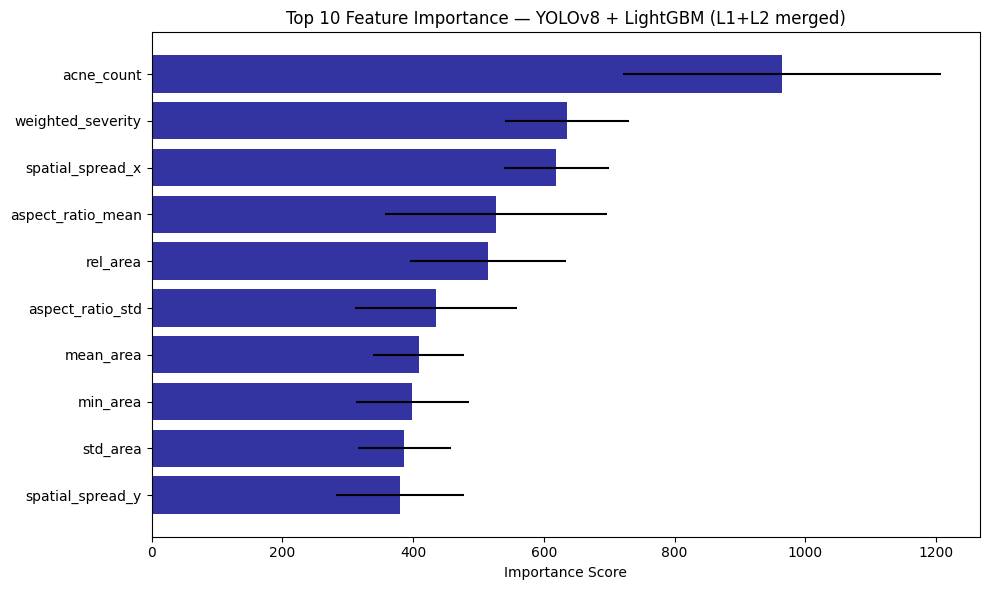

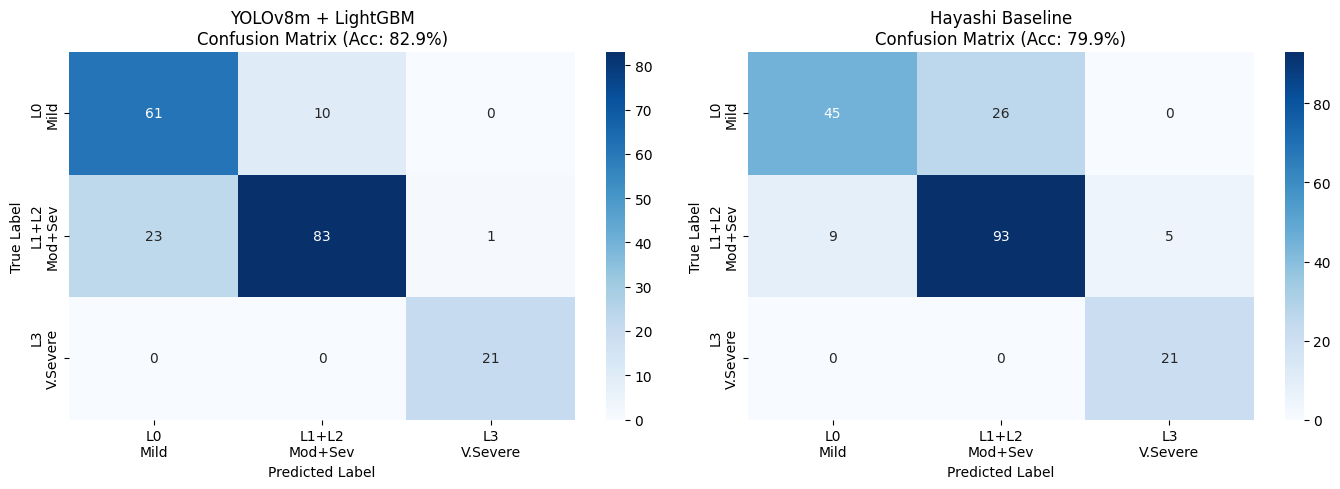

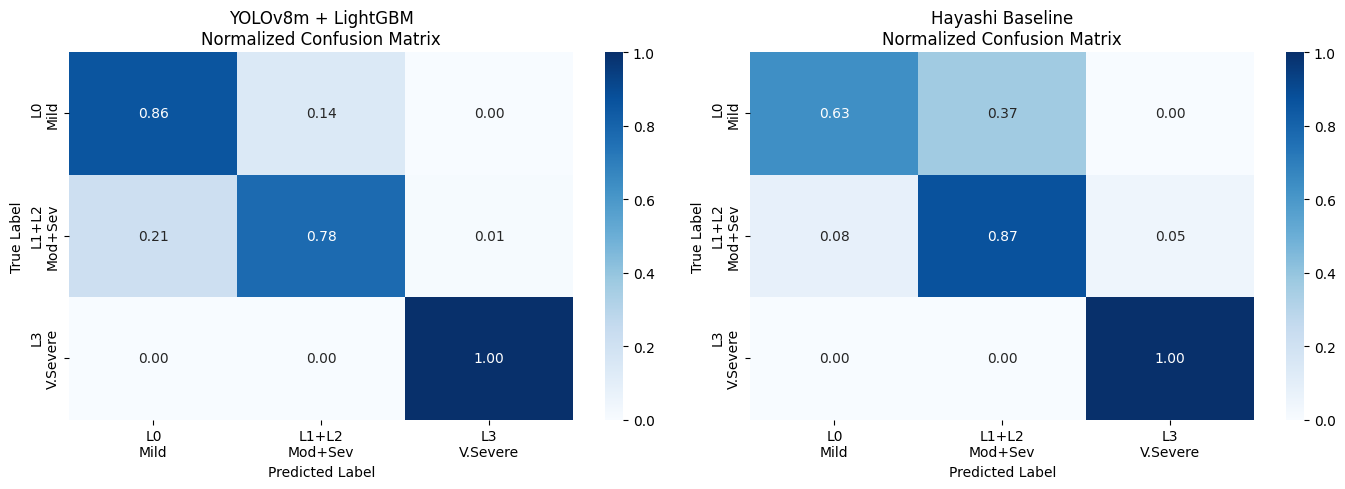


LightGBM (YOLOv8 features) — L0 / L1+2 / L3

Class              TP    TN    FP    FN     Pre      Sn      Sp      F1      YI
  ---------------------------------------------------------------------------
  Level 0          61   105    23    10  0.7262  0.8592  0.8203  0.7871  0.6795
  Level 1+2        83    82    10    24  0.8925  0.7757  0.8913  0.8300  0.6670
  Level 3          21   177     1     0  0.9545  1.0000  0.9944  0.9767  0.9944
  ---------------------------------------------------------------------------
  Macro Avg                              0.8577  0.8783  0.9020  0.8646  0.7803

  Overall Accuracy : 82.91%

Hayashi Baseline — L0 / L1+2 / L3

Class              TP    TN    FP    FN     Pre      Sn      Sp      F1      YI
  ---------------------------------------------------------------------------
  Level 0          45   119     9    26  0.8333  0.6338  0.9297  0.7200  0.5635
  Level 1+2        93    66    26    14  0.7815  0.8692  0.7174  0.8230  0.5866
  Level 3      

In [ ]:
import re
import random
import numpy as np
import pandas as pd
import lightgbm as lgb
from pathlib import Path
from PIL import Image
from ultralytics import YOLO
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, f1_score
from sklearn.model_selection import StratifiedKFold
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import json
from tqdm import tqdm
import torch

# ── Seed ──────────────────────────────────────────────────
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False
    print(f" Global seed set to: {seed}")

set_seed(42)

# ── Paths ─────────────────────────────────────────────────
BASE_DIR    = Path('/content/drive/MyDrive/yolo_acne_detection')
TRAIN_DIR   = BASE_DIR / 'dataset' / 'train'
VAL_DIR     = BASE_DIR / 'dataset' / 'val'
TEST_DIR    = BASE_DIR / 'dataset' / 'test'
BEST_MODEL  = BASE_DIR / 'runs' / 'yolov8m_acne' / 'weights' / 'best.pt'
RESULTS_DIR = BASE_DIR / 'results' / 'classification_yolo_L1L2merged'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# ── Settings ──────────────────────────────────────────────
SCORE_THRESHOLD = 0.1
MAX_DETECTIONS  = 250
DEVICE          = 'cuda' if torch.cuda.is_available() else 'cpu'

print(f" Device          : {DEVICE}")
print(f"Score threshold : {SCORE_THRESHOLD}")

# ── Classes: L0, L1+L2, L3 ────────────────────────────────
# merge_levels: 0→0, 1→1, 2→1, 3→2
CLASS_LABELS = ['Level 0', 'Level 1+2', 'Level 3']
N_CLASSES    = 3


# 1. LOAD YOLO MODEL

print(f"\n Loading YOLOv8 model: {BEST_MODEL}")
model = YOLO(str(BEST_MODEL))
print(f" Model loaded")


# 2. HELPERS

def get_level(filename):
    match = re.search(r'levle(\d)', filename.lower())
    return int(match.group(1)) if match else None

def merge_levels(labels):
    # 0→0, 1→1, 2→1, 3→2
    result = labels.copy()
    result[labels == 2] = 1
    result[labels == 3] = 2
    return result

def hayashi_grade(count):
    if count <= 5:
        return 0          # L0
    elif count <= 50:
        return 1          # L1+L2
    else:
        return 2          # L3


# 3. FEATURE EXTRACTION

def extract_features(img_path):
    try:
        img          = Image.open(img_path).convert('RGB')
        img_w, img_h = img.size
        img_area     = img_w * img_h
    except Exception as e:
        print(f"  Error loading {img_path}: {e}")
        return None

    results = model(
        img_path,
        conf    = SCORE_THRESHOLD,
        max_det = MAX_DETECTIONS,
        verbose = False,
        device  = DEVICE
    )

    boxes  = results[0].boxes.xyxy.cpu().numpy()
    scores = results[0].boxes.conf.cpu().numpy()
    count  = len(boxes)

    if count == 0:
        return {
            'acne_count'        : 0,
            'weighted_severity' : 0.0,
            'density'           : 0.0,
            'mean_area'         : 0.0,
            'std_area'          : 0.0,
            'min_area'          : 0.0,
            'max_area'          : 0.0,
            'rel_area'          : 0.0,
            'spatial_spread_x'  : 0.0,
            'spatial_spread_y'  : 0.0,
            'aspect_ratio_mean' : 0.0,
            'aspect_ratio_std'  : 0.0,
            'mean_score'        : 0.0,
            'max_score'         : 0.0,
            'min_score'         : 0.0,
            'std_score'         : 0.0,
        }

    widths        = boxes[:, 2] - boxes[:, 0]
    heights       = boxes[:, 3] - boxes[:, 1]
    areas         = widths * heights
    aspect_ratios = widths / (heights + 1e-6)
    cx            = (boxes[:, 0] + boxes[:, 2]) / 2
    cy            = (boxes[:, 1] + boxes[:, 3]) / 2

    weighted_sum      = np.sum(scores * (areas / img_area))
    weighted_severity = (200 / np.pi) * np.arctan(20 * weighted_sum)

    return {
        'acne_count'        : count,
        'weighted_severity' : float(weighted_severity),
        'density'           : count / (img_area / 1_000_000),
        'mean_area'         : float(np.mean(areas)),
        'std_area'          : float(np.std(areas)),
        'min_area'          : float(np.min(areas)),
        'max_area'          : float(np.max(areas)),
        'rel_area'          : float(np.sum(areas) / img_area),
        'spatial_spread_x'  : float(np.std(cx)) if count > 1 else 0.0,
        'spatial_spread_y'  : float(np.std(cy)) if count > 1 else 0.0,
        'aspect_ratio_mean' : float(np.mean(aspect_ratios)),
        'aspect_ratio_std'  : float(np.std(aspect_ratios)),
        'mean_score'        : float(np.mean(scores)),
        'max_score'         : float(np.max(scores)),
        'min_score'         : float(np.min(scores)),
        'std_score'         : float(np.std(scores)),
    }


# 4. PROCESS SPLIT

def process_split(split_dir, split_name):
    img_dir   = split_dir / 'images'
    files     = sorted(img_dir.glob('*.jpg'))
    features  = []
    labels    = []
    hayashi   = []
    filenames = []
    skipped   = 0

    print(f"\n Processing {split_name} ({len(files)} images)...")

    for img_path in tqdm(files, desc=split_name):
        level = get_level(img_path.name)
        if level is None:
            skipped += 1
            continue

        feat = extract_features(img_path)
        if feat is None:
            skipped += 1
            continue

        features.append(feat)
        labels.append(level)
        hayashi.append(hayashi_grade(feat['acne_count']))
        filenames.append(img_path.name)

    print(f"   Processed: {len(features)} images, {skipped} skipped")
    return (
        pd.DataFrame(features),
        np.array(labels),
        np.array(hayashi),
        np.array(filenames)
    )


# 5. FEATURE EXTRACTION

print("\n" + "=" * 70)
print("🔍 FEATURE EXTRACTION")
print("=" * 70)

X_train, y_train, h_train, f_train = process_split(TRAIN_DIR, 'train')
X_val,   y_val,   h_val,   f_val   = process_split(VAL_DIR,   'val')
X_test,  y_test,  h_test,  f_test  = process_split(TEST_DIR,  'test')

# Merge L1+L2 → 1, L3 → 2
y_train_merged = merge_levels(y_train)
y_val_merged   = merge_levels(y_val)
y_test_merged  = merge_levels(y_test)
h_test_merged = h_test

X_train_full = pd.concat([X_train, X_val], ignore_index=True)
y_train_full = np.concatenate([y_train_merged, y_val_merged])

print(f"\n Dataset sizes:")
print(f"  Train+Val : {len(X_train_full)} images")
print(f"  Test      : {len(X_test)} images")

print(f"\n Box count stats (test):")
print(f"  Total boxes    : {X_test['acne_count'].sum()}")
print(f"  Mean per image : {X_test['acne_count'].mean():.1f}")
print(f"  Images with 0  : {(X_test['acne_count'] == 0).sum()}/{len(X_test)}")

print(f"\n Label distribution (test, L1+L2 merged):")
for lvl, name in enumerate(CLASS_LABELS):
    count = np.sum(y_test_merged == lvl)
    pct   = count / len(y_test_merged) * 100
    print(f"  {name}: {count:4d} ({pct:.1f}%)")


# 6. LIGHTGBM

print("\n" + "=" * 70)
print(" LIGHTGBM — 5-Fold Stratified CV + Early Stopping")
print("=" * 70)

N_FOLDS        = 5
skf            = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)
test_preds_all = np.zeros((len(X_test), N_CLASSES))
fold_models    = []
fold_scores    = []
feature_names  = list(X_train_full.columns)

for fold, (train_idx, val_idx) in enumerate(skf.split(X_train_full, y_train_full)):
    print(f"\n  📂 Fold {fold+1}/{N_FOLDS}")

    X_fold_train = X_train_full.iloc[train_idx]
    y_fold_train = y_train_full[train_idx]
    X_fold_val   = X_train_full.iloc[val_idx]
    y_fold_val   = y_train_full[val_idx]

    lgbm_fold = lgb.LGBMClassifier(
        n_estimators      = 200,
        learning_rate     = 0.05,
        max_depth         = 6,
        num_leaves        = 31,
        min_child_samples = 5,
        subsample         = 0.8,
        colsample_bytree  = 0.8,
        class_weight      = 'balanced',
        random_state      = 42,
        verbose           = -1,
        n_jobs            = -1,
    )

    lgbm_fold.fit(
        X_fold_train, y_fold_train,
        eval_set  = [(X_fold_val, y_fold_val)],
        callbacks = [lgb.early_stopping(30, verbose=False),
                     lgb.log_evaluation(period=-1)],
    )

    print(f"    Best iteration : {lgbm_fold.best_iteration_}")
    test_preds_all += lgbm_fold.predict_proba(X_test) / N_FOLDS

    fold_pred = lgbm_fold.predict(X_fold_val)
    fold_acc  = accuracy_score(y_fold_val, fold_pred)
    fold_f1   = f1_score(y_fold_val, fold_pred, average='weighted')
    fold_scores.append({'acc': fold_acc, 'f1': fold_f1})
    fold_models.append(lgbm_fold)

    print(f"    Fold Accuracy  : {fold_acc*100:.2f}%")
    print(f"    Fold F1-Score  : {fold_f1*100:.2f}%")

print(f"\n📊 Cross-Validation Summary:")
print(f"  Mean Accuracy : {np.mean([s['acc'] for s in fold_scores])*100:.2f}%"
      f" ± {np.std([s['acc'] for s in fold_scores])*100:.2f}%")
print(f"  Mean F1-Score : {np.mean([s['f1'] for s in fold_scores])*100:.2f}%"
      f" ± {np.std([s['f1'] for s in fold_scores])*100:.2f}%")

y_pred       = np.argmax(test_preds_all, axis=1)
y_pred_proba = test_preds_all


# 7. RESULTS

print("\n" + "=" * 70)
print(" FINAL RESULTS — 3 Classes (Level 0 / Level 1+2 / Level 3)")
print("=" * 70)

acc_lgbm = accuracy_score(y_test_merged, y_pred)
f1_lgbm  = f1_score(y_test_merged, y_pred, average='weighted')

print(f"\n LightGBM Ensemble (YOLOv8 features)")
print(f"  Accuracy : {acc_lgbm*100:.2f}%")
print(f"  F1-Score : {f1_lgbm*100:.2f}%")
print(f"\n{classification_report(y_test_merged, y_pred, target_names=CLASS_LABELS, digits=4)}")

acc_hayashi = accuracy_score(y_test_merged, h_test_merged)
f1_hayashi  = f1_score(y_test_merged, h_test_merged, average='weighted')

print(f"\n📏 Hayashi Baseline")
print(f"  Accuracy : {acc_hayashi*100:.2f}%")
print(f"  F1-Score : {f1_hayashi*100:.2f}%")
print(f"\n{classification_report(y_test_merged, h_test_merged, target_names=CLASS_LABELS, digits=4)}")

print(f"\n📈 Improvement over Hayashi:")
print(f"  Accuracy : +{(acc_lgbm - acc_hayashi)*100:.2f}%")
print(f"  F1-Score : +{(f1_lgbm  - f1_hayashi)*100:.2f}%")


# 8. VISUALIZATIONS

importance_matrix = np.array([m.feature_importances_ for m in fold_models])
importance_df     = pd.DataFrame({
    'feature'   : feature_names,
    'importance': importance_matrix.mean(axis=0),
    'std'       : importance_matrix.std(axis=0),
}).sort_values('importance', ascending=False)

print(f"\n Top 10 Important Features:")
print(importance_df.head(10).to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 6))
top_f = importance_df.head(10)
ax.barh(top_f['feature'], top_f['importance'],
        xerr=top_f['std'], color='#00008B', alpha=0.8)
ax.set_xlabel('Importance Score')
ax.set_title('Top 10 Feature Importance — YOLOv8 + LightGBM (L1+L2 merged)')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'feature_importance_yolo.png', dpi=300, bbox_inches='tight')
plt.show()


# CONFUSION MATRICES — RAW + NORMALIZED


tick_labels = ['L0\nMild', 'L1+L2\nMod+Sev', 'L3\nV.Severe']

cm_lgbm = confusion_matrix(y_test_merged, y_pred)
cm_hayashi = confusion_matrix(y_test_merged, h_test_merged)

cm_lgbm_norm = cm_lgbm.astype(float) / cm_lgbm.sum(axis=1, keepdims=True)
cm_hayashi_norm = cm_hayashi.astype(float) / cm_hayashi.sum(axis=1, keepdims=True)

cm_lgbm_norm = np.nan_to_num(cm_lgbm_norm)
cm_hayashi_norm = np.nan_to_num(cm_hayashi_norm)

# ---------- Non-normalized ----------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(
    cm_lgbm,
    annot=True,
    fmt='d',
    cmap='Blues',
    ax=axes[0],
    xticklabels=tick_labels,
    yticklabels=tick_labels,
    cbar=True
)
axes[0].set_title(f'YOLOv8m + LightGBM\nConfusion Matrix (Acc: {acc_lgbm*100:.1f}%)')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

sns.heatmap(
    cm_hayashi,
    annot=True,
    fmt='d',
    cmap='Blues',
    ax=axes[1],
    xticklabels=tick_labels,
    yticklabels=tick_labels,
    cbar=True
)
axes[1].set_title(f'Hayashi Baseline\nConfusion Matrix (Acc: {acc_hayashi*100:.1f}%)')
axes[1].set_ylabel('True Label')
axes[1].set_xlabel('Predicted Label')

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'confusion_matrices_yolo_raw.png', dpi=300, bbox_inches='tight')
plt.show()


# ---------- Normalized ----------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(
    cm_lgbm_norm,
    annot=True,
    fmt='.2f',
    cmap='Blues',
    ax=axes[0],
    xticklabels=tick_labels,
    yticklabels=tick_labels,
    vmin=0,
    vmax=1,
    cbar=True
)
axes[0].set_title('YOLOv8m + LightGBM\nNormalized Confusion Matrix')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

sns.heatmap(
    cm_hayashi_norm,
    annot=True,
    fmt='.2f',
    cmap='Blues',
    ax=axes[1],
    xticklabels=tick_labels,
    yticklabels=tick_labels,
    vmin=0,
    vmax=1,
    cbar=True
)
axes[1].set_title('Hayashi Baseline\nNormalized Confusion Matrix')
axes[1].set_ylabel('True Label')
axes[1].set_xlabel('Predicted Label')

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'confusion_matrices_yolo_normalized.png', dpi=300, bbox_inches='tight')
plt.show()


#  OVR MACRO-AVERAGING METRICS

CLASS_LABELS_YOLO = ['Level 0', 'Level 1+2', 'Level 3']

def compute_ovr_metrics(y_true, y_pred, class_labels):
    cm        = confusion_matrix(y_true, y_pred)
    per_class = []

    print(f"\n{'Class':<15} {'TP':>5} {'TN':>5} {'FP':>5} {'FN':>5} "
          f"{'Pre':>7} {'Sn':>7} {'Sp':>7} {'F1':>7} {'YI':>7}")
    print("  " + "-" * 75)

    for i in range(len(class_labels)):
        TP = cm[i, i]
        FN = cm[i, :].sum() - TP
        FP = cm[:, i].sum() - TP
        TN = cm.sum() - TP - FN - FP

        Pre = TP / (TP + FP) if (TP + FP) > 0 else 0.0
        Sn  = TP / (TP + FN) if (TP + FN) > 0 else 0.0
        Sp  = TN / (TN + FP) if (TN + FP) > 0 else 0.0
        F1  = 2 * Pre * Sn / (Pre + Sn) if (Pre + Sn) > 0 else 0.0
        YI  = Sn + Sp - 1

        per_class.append({
            'class': class_labels[i],
            'TP': TP, 'TN': TN, 'FP': FP, 'FN': FN,
            'Pre': Pre, 'Sn': Sn, 'Sp': Sp, 'F1': F1, 'YI': YI,
        })

        print(f"  {class_labels[i]:<13} {TP:>5} {TN:>5} {FP:>5} {FN:>5} "
              f"{Pre:>7.4f} {Sn:>7.4f} {Sp:>7.4f} {F1:>7.4f} {YI:>7.4f}")

    macro_pre = np.mean([r['Pre'] for r in per_class])
    macro_sn  = np.mean([r['Sn']  for r in per_class])
    macro_sp  = np.mean([r['Sp']  for r in per_class])
    macro_f1  = np.mean([r['F1']  for r in per_class])
    macro_yi  = np.mean([r['YI']  for r in per_class])
    overall_acc = accuracy_score(y_true, y_pred)

    print("  " + "-" * 75)
    print(f"  {'Macro Avg':<13} {'':>5} {'':>5} {'':>5} {'':>5} "
          f"{macro_pre:>7.4f} {macro_sn:>7.4f} {macro_sp:>7.4f} "
          f"{macro_f1:>7.4f} {macro_yi:>7.4f}")
    print(f"\n  Overall Accuracy : {overall_acc*100:.2f}%")

    return {
        'per_class': per_class,
        'macro_pre': macro_pre,
        'macro_sn' : macro_sn,
        'macro_sp' : macro_sp,
        'macro_f1' : macro_f1,
        'macro_yi' : macro_yi,
        'accuracy' : overall_acc,
    }

print("\nLightGBM (YOLOv8 features) — L0 / L1+2 / L3")
yolo_lgbm_metrics = compute_ovr_metrics(y_test_merged, y_pred, CLASS_LABELS_YOLO)

print("\nHayashi Baseline — L0 / L1+2 / L3")
yolo_hayashi_metrics = compute_ovr_metrics(y_test_merged, h_test_merged, CLASS_LABELS_YOLO)

print("\n" + "=" * 70)
print("SUMMARY — LightGBM vs Hayashi (YOLOv8)")
print("=" * 70)
print(f"\n{'Metric':<12} {'LightGBM':>10} {'Hayashi':>10} {'Delta':>10}")
print("  " + "-" * 42)
for label, key in [
    ('Accuracy',    'accuracy'),
    ('Precision',   'macro_pre'),
    ('Sensitivity', 'macro_sn'),
    ('Specificity', 'macro_sp'),
    ('F1-Score',    'macro_f1'),
    ('Youden',      'macro_yi'),
]:
    lgbm_val    = yolo_lgbm_metrics[key]
    hayashi_val = yolo_hayashi_metrics[key]
    delta       = lgbm_val - hayashi_val
    print(f"  {label:<12} {lgbm_val*100:>9.2f}% "
          f"{hayashi_val*100:>9.2f}% {delta*100:>+9.2f}%")

rows = []
for r in yolo_lgbm_metrics['per_class']:
    rows.append({
        'model'      : 'LightGBM_YOLO_3class',
        'class'      : r['class'],
        'TP': r['TP'], 'TN': r['TN'], 'FP': r['FP'], 'FN': r['FN'],
        'Precision'  : round(r['Pre'], 4),
        'Sensitivity': round(r['Sn'],  4),
        'Specificity': round(r['Sp'],  4),
        'F1'         : round(r['F1'],  4),
        'Youden'     : round(r['YI'],  4),
    })
for r in yolo_hayashi_metrics['per_class']:
    rows.append({
        'model'      : 'Hayashi_YOLO_3class',
        'class'      : r['class'],
        'TP': r['TP'], 'TN': r['TN'], 'FP': r['FP'], 'FN': r['FN'],
        'Precision'  : round(r['Pre'], 4),
        'Sensitivity': round(r['Sn'],  4),
        'Specificity': round(r['Sp'],  4),
        'F1'         : round(r['F1'],  4),
        'Youden'     : round(r['YI'],  4),
    })

pd.DataFrame(rows).to_csv(
    RESULTS_DIR / 'ovr_metrics_yolo_3class.csv', index=False)

np.save(RESULTS_DIR / 'y_pred_proba_yolo.npy', y_pred_proba)
np.save(RESULTS_DIR / 'y_test_merged_yolo.npy', y_test_merged)
np.save(RESULTS_DIR / 'y_pred_yolo.npy', y_pred)

print(f"\nAll saved to: {RESULTS_DIR}")


# SAVE

with open(RESULTS_DIR / 'lgbm_ensemble_yolo.pkl', 'wb') as f:
    pickle.dump(fold_models, f)

with open(RESULTS_DIR / 'feature_names_yolo.pkl', 'wb') as f:
    pickle.dump(feature_names, f)

metadata = {
    'detection_model' : 'YOLOv8m',
    'features'        : feature_names,
    'classes'         : CLASS_LABELS,
    'n_classes'       : N_CLASSES,
    'accuracy'        : float(acc_lgbm),
    'f1_score'        : float(f1_lgbm),
    'cv_mean_acc'     : float(np.mean([s['acc'] for s in fold_scores])),
    'cv_std_acc'      : float(np.std([s['acc']  for s in fold_scores])),
    'cv_mean_f1'      : float(np.mean([s['f1']  for s in fold_scores])),
    'cv_std_f1'       : float(np.std([s['f1']   for s in fold_scores])),
    'train_samples'   : len(X_train_full),
    'test_samples'    : len(X_test),
    'score_threshold' : SCORE_THRESHOLD,
    'max_detections'  : MAX_DETECTIONS,
    'n_folds'         : N_FOLDS,
    'label_merging'   : 'Level 1 and 2 merged into single class',
}
with open(RESULTS_DIR / 'metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

predictions_df = pd.DataFrame({
    'filename'         : f_test,
    'true_level'       : y_test,
    'true_level_merged': y_test_merged,
    'pred_level'       : y_pred,
    'hayashi_level'    : h_test_merged,
    'confidence'       : np.max(y_pred_proba, axis=1),
})
predictions_df.to_csv(RESULTS_DIR / 'predictions_yolo.csv', index=False)

print("\n" + "=" * 70)
print(" CLASSIFICATION COMPLETE — YOLOv8 + LightGBM (L1+L2 merged)")
print("=" * 70)
print(f" Accuracy : {acc_lgbm*100:.2f}%")
print(f" F1-Score : {f1_lgbm*100:.2f}%")
print(f" Results  : {RESULTS_DIR}")
print("=" * 70)

# YOLOv8 LIGHTGBM Acne Grading (4 Class)
Outputs (Models, Plots, CSVs) are saved to this directory



Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Global seed set to: 42
Device          : cuda
Score threshold : 0.1

Loading YOLOv8 model: /content/drive/MyDrive/yolo_acne_detection/runs/yolov8m_acne/weights/best.pt
Model loaded

FEATURE EXTRACTION

Processing train (1345 images)...


train: 100%|██████████| 1345/1345 [01:21<00:00, 16.57it/s]


  Processed: 1345 images, 0 skipped

Processing val (198 images)...


val: 100%|██████████| 198/198 [00:11<00:00, 16.80it/s]


  Processed: 198 images, 0 skipped

Processing test (199 images)...


test: 100%|██████████| 199/199 [00:11<00:00, 17.04it/s]


  Processed: 199 images, 0 skipped

Dataset sizes:
  Train+Val : 1543 images
  Test      : 199 images

Box count stats (test):
  Total boxes    : 5031
  Mean per image : 25.3
  Images with 0  : 8/199

Label distribution (test, four class):
  Level 0:   71 (35.7%)
  Level 1:   87 (43.7%)
  Level 2:   20 (10.1%)
  Level 3:   21 (10.6%)

LIGHTGBM — 5-Fold Stratified CV + Early Stopping

  Fold 1/5
    Best iteration : 73
    Fold Accuracy  : 83.50%
    Fold F1-Score  : 83.58%

  Fold 2/5
    Best iteration : 73
    Fold Accuracy  : 78.96%
    Fold F1-Score  : 78.91%

  Fold 3/5
    Best iteration : 75
    Fold Accuracy  : 81.55%
    Fold F1-Score  : 81.40%

  Fold 4/5
    Best iteration : 94
    Fold Accuracy  : 78.90%
    Fold F1-Score  : 78.56%

  Fold 5/5
    Best iteration : 61
    Fold Accuracy  : 78.25%
    Fold F1-Score  : 78.23%

Cross-Validation Summary:
  Mean Accuracy : 80.23% +/- 1.99%
  Mean F1-Score : 80.13% +/- 2.05%

FINAL RESULTS — 4 Classes (Level 0 / Level 1 / Level 2 /

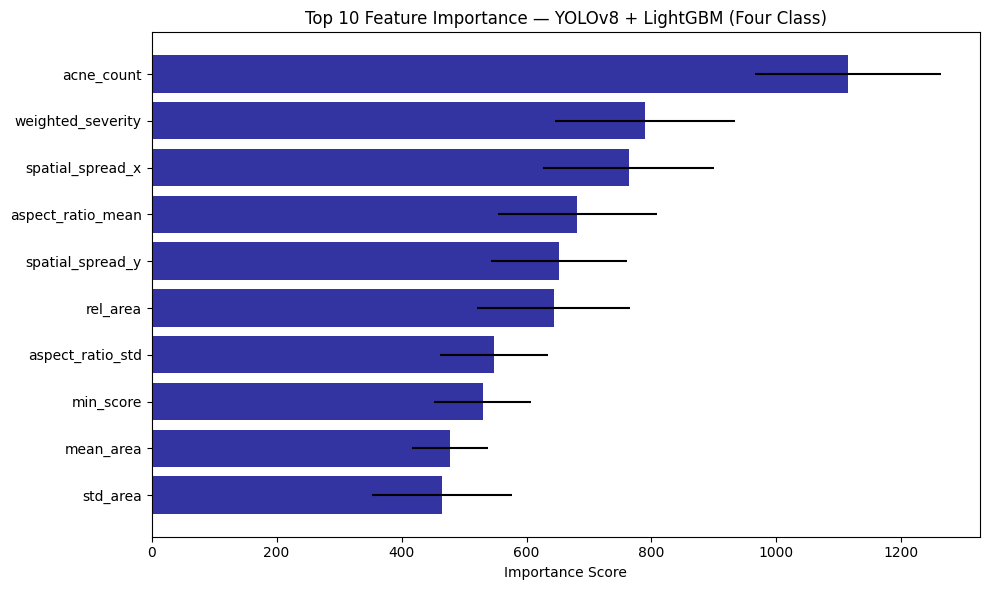

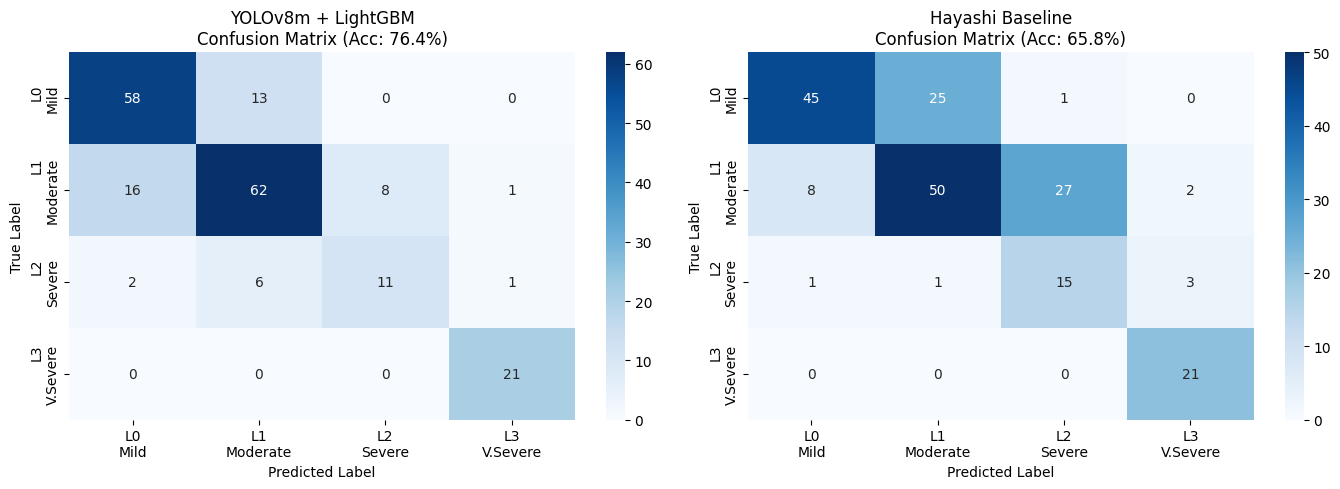

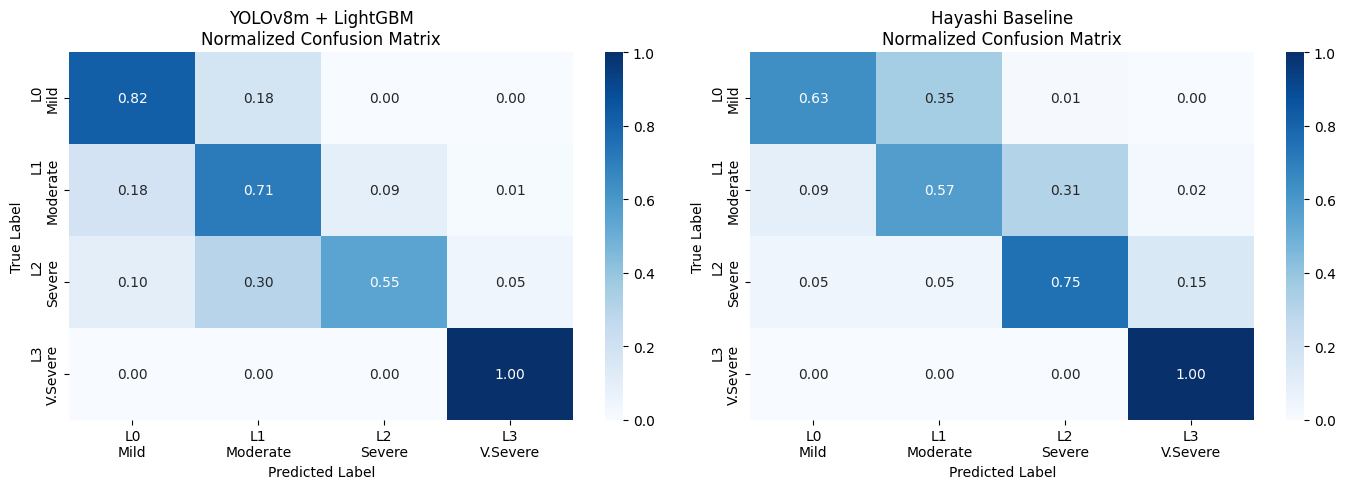


LightGBM (YOLOv8 features) — Four Class

Class              TP    TN    FP    FN     Pre      Sn      Sp      F1      YI
  ---------------------------------------------------------------------------
  Level 0          58   110    18    13  0.7632  0.8169  0.8594  0.7891  0.6763
  Level 1          62    93    19    25  0.7654  0.7126  0.8304  0.7381  0.5430
  Level 2          11   171     8     9  0.5789  0.5500  0.9553  0.5641  0.5053
  Level 3          21   176     2     0  0.9130  1.0000  0.9888  0.9545  0.9888
  ---------------------------------------------------------------------------
  Macro Avg                              0.7551  0.7699  0.9085  0.7615  0.6783

  Overall Accuracy : 76.38%

Hayashi Baseline — Four Class

Class              TP    TN    FP    FN     Pre      Sn      Sp      F1      YI
  ---------------------------------------------------------------------------
  Level 0          45   119     9    26  0.8333  0.6338  0.9297  0.7200  0.5635
  Level 1          50  

In [ ]:
import re
import random
import numpy as np
import pandas as pd
import lightgbm as lgb
from pathlib import Path
from PIL import Image
from ultralytics import YOLO
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, f1_score
from sklearn.model_selection import StratifiedKFold
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import json
from tqdm import tqdm
import torch

# ── Seed ──────────────────────────────────────────────────
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False
    print(f"Global seed set to: {seed}")

set_seed(42)

# ── Paths ──────────────────────────────────────────────────
BASE_DIR    = Path('/content/drive/MyDrive/yolo_acne_detection')
TRAIN_DIR   = BASE_DIR / 'dataset' / 'train'
VAL_DIR     = BASE_DIR / 'dataset' / 'val'
TEST_DIR    = BASE_DIR / 'dataset' / 'test'
BEST_MODEL  = BASE_DIR / 'runs' / 'yolov8m_acne' / 'weights' / 'best.pt'
RESULTS_DIR = BASE_DIR / 'results' / 'classification_yolo_four_class'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# ── Settings ───────────────────────────────────────────────
SCORE_THRESHOLD = 0.1
MAX_DETECTIONS  = 250
DEVICE          = 'cuda' if torch.cuda.is_available() else 'cpu'

print(f"Device          : {DEVICE}")
print(f"Score threshold : {SCORE_THRESHOLD}")

# ── Classes: L0, L1, L2, L3 (no merging) ──────────────────
CLASS_LABELS = ['Level 0', 'Level 1', 'Level 2', 'Level 3']
N_CLASSES    = 4


# 1. LOAD YOLO MODEL

print(f"\nLoading YOLOv8 model: {BEST_MODEL}")
model = YOLO(str(BEST_MODEL))
print(f"Model loaded")


# 2. HELPERS

def get_level(filename):
    match = re.search(r'levle(\d)', filename.lower())
    return int(match.group(1)) if match else None

def hayashi_grade(count):
    if count <= 5:
        return 0
    elif count <= 20:
        return 1
    elif count <= 50:
        return 2
    else:
        return 3


# 3. FEATURE EXTRACTION

def extract_features(img_path):
    try:
        img          = Image.open(img_path).convert('RGB')
        img_w, img_h = img.size
        img_area     = img_w * img_h
    except Exception as e:
        print(f"Error loading {img_path}: {e}")
        return None

    results = model(
        img_path,
        conf    = SCORE_THRESHOLD,
        max_det = MAX_DETECTIONS,
        verbose = False,
        device  = DEVICE
    )

    boxes  = results[0].boxes.xyxy.cpu().numpy()
    scores = results[0].boxes.conf.cpu().numpy()
    count  = len(boxes)

    if count == 0:
        return {
            'acne_count'        : 0,
            'weighted_severity' : 0.0,
            'density'           : 0.0,
            'mean_area'         : 0.0,
            'std_area'          : 0.0,
            'min_area'          : 0.0,
            'max_area'          : 0.0,
            'rel_area'          : 0.0,
            'spatial_spread_x'  : 0.0,
            'spatial_spread_y'  : 0.0,
            'aspect_ratio_mean' : 0.0,
            'aspect_ratio_std'  : 0.0,
            'mean_score'        : 0.0,
            'max_score'         : 0.0,
            'min_score'         : 0.0,
            'std_score'         : 0.0,
        }

    widths        = boxes[:, 2] - boxes[:, 0]
    heights       = boxes[:, 3] - boxes[:, 1]
    areas         = widths * heights
    aspect_ratios = widths / (heights + 1e-6)
    cx            = (boxes[:, 0] + boxes[:, 2]) / 2
    cy            = (boxes[:, 1] + boxes[:, 3]) / 2

    weighted_sum      = np.sum(scores * (areas / img_area))
    weighted_severity = (200 / np.pi) * np.arctan(20 * weighted_sum)

    return {
        'acne_count'        : count,
        'weighted_severity' : float(weighted_severity),
        'density'           : count / (img_area / 1_000_000),
        'mean_area'         : float(np.mean(areas)),
        'std_area'          : float(np.std(areas)),
        'min_area'          : float(np.min(areas)),
        'max_area'          : float(np.max(areas)),
        'rel_area'          : float(np.sum(areas) / img_area),
        'spatial_spread_x'  : float(np.std(cx)) if count > 1 else 0.0,
        'spatial_spread_y'  : float(np.std(cy)) if count > 1 else 0.0,
        'aspect_ratio_mean' : float(np.mean(aspect_ratios)),
        'aspect_ratio_std'  : float(np.std(aspect_ratios)),
        'mean_score'        : float(np.mean(scores)),
        'max_score'         : float(np.max(scores)),
        'min_score'         : float(np.min(scores)),
        'std_score'         : float(np.std(scores)),
    }


# 4. PROCESS SPLIT

def process_split(split_dir, split_name):
    img_dir   = split_dir / 'images'
    files     = sorted(img_dir.glob('*.jpg'))
    features  = []
    labels    = []
    hayashi   = []
    filenames = []
    skipped   = 0

    print(f"\nProcessing {split_name} ({len(files)} images)...")

    for img_path in tqdm(files, desc=split_name):
        level = get_level(img_path.name)
        if level is None:
            skipped += 1
            continue

        feat = extract_features(img_path)
        if feat is None:
            skipped += 1
            continue

        features.append(feat)
        labels.append(level)
        hayashi.append(hayashi_grade(feat['acne_count']))
        filenames.append(img_path.name)

    print(f"  Processed: {len(features)} images, {skipped} skipped")
    return (
        pd.DataFrame(features),
        np.array(labels),
        np.array(hayashi),
        np.array(filenames)
    )


# 5. FEATURE EXTRACTION

print("\n" + "=" * 70)
print("FEATURE EXTRACTION")
print("=" * 70)

X_train, y_train, h_train, f_train = process_split(TRAIN_DIR, 'train')
X_val,   y_val,   h_val,   f_val   = process_split(VAL_DIR,   'val')
X_test,  y_test,  h_test,  f_test  = process_split(TEST_DIR,  'test')

X_train_full = pd.concat([X_train, X_val], ignore_index=True)
y_train_full = np.concatenate([y_train, y_val])

print(f"\nDataset sizes:")
print(f"  Train+Val : {len(X_train_full)} images")
print(f"  Test      : {len(X_test)} images")

print(f"\nBox count stats (test):")
print(f"  Total boxes    : {X_test['acne_count'].sum()}")
print(f"  Mean per image : {X_test['acne_count'].mean():.1f}")
print(f"  Images with 0  : {(X_test['acne_count'] == 0).sum()}/{len(X_test)}")

print(f"\nLabel distribution (test, four class):")
for lvl, name in enumerate(CLASS_LABELS):
    count = np.sum(y_test == lvl)
    pct   = count / len(y_test) * 100
    print(f"  {name}: {count:4d} ({pct:.1f}%)")


# 6. LIGHTGBM

print("\n" + "=" * 70)
print("LIGHTGBM — 5-Fold Stratified CV + Early Stopping")
print("=" * 70)

N_FOLDS        = 5
skf            = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)
test_preds_all = np.zeros((len(X_test), N_CLASSES))
fold_models    = []
fold_scores    = []
feature_names  = list(X_train_full.columns)

for fold, (train_idx, val_idx) in enumerate(skf.split(X_train_full, y_train_full)):
    print(f"\n  Fold {fold+1}/{N_FOLDS}")

    X_fold_train = X_train_full.iloc[train_idx]
    y_fold_train = y_train_full[train_idx]
    X_fold_val   = X_train_full.iloc[val_idx]
    y_fold_val   = y_train_full[val_idx]

    lgbm_fold = lgb.LGBMClassifier(
        n_estimators      = 200,
        learning_rate     = 0.05,
        max_depth         = 6,
        num_leaves        = 31,
        min_child_samples = 5,
        subsample         = 0.8,
        colsample_bytree  = 0.8,
        class_weight      = 'balanced',
        random_state      = 42,
        verbose           = -1,
        n_jobs            = -1,
    )

    lgbm_fold.fit(
        X_fold_train, y_fold_train,
        eval_set  = [(X_fold_val, y_fold_val)],
        callbacks = [lgb.early_stopping(30, verbose=False),
                     lgb.log_evaluation(period=-1)],
    )

    print(f"    Best iteration : {lgbm_fold.best_iteration_}")
    test_preds_all += lgbm_fold.predict_proba(X_test) / N_FOLDS

    fold_pred = lgbm_fold.predict(X_fold_val)
    fold_acc  = accuracy_score(y_fold_val, fold_pred)
    fold_f1   = f1_score(y_fold_val, fold_pred, average='weighted')
    fold_scores.append({'acc': fold_acc, 'f1': fold_f1})
    fold_models.append(lgbm_fold)

    print(f"    Fold Accuracy  : {fold_acc*100:.2f}%")
    print(f"    Fold F1-Score  : {fold_f1*100:.2f}%")

print(f"\nCross-Validation Summary:")
print(f"  Mean Accuracy : {np.mean([s['acc'] for s in fold_scores])*100:.2f}%"
      f" +/- {np.std([s['acc'] for s in fold_scores])*100:.2f}%")
print(f"  Mean F1-Score : {np.mean([s['f1'] for s in fold_scores])*100:.2f}%"
      f" +/- {np.std([s['f1'] for s in fold_scores])*100:.2f}%")

y_pred       = np.argmax(test_preds_all, axis=1)
y_pred_proba = test_preds_all


# 7. RESULTS

print("\n" + "=" * 70)
print("FINAL RESULTS — 4 Classes (Level 0 / Level 1 / Level 2 / Level 3)")
print("=" * 70)

acc_lgbm = accuracy_score(y_test, y_pred)
f1_lgbm  = f1_score(y_test, y_pred, average='weighted')

print(f"\nLightGBM Ensemble (YOLOv8 features)")
print(f"  Accuracy : {acc_lgbm*100:.2f}%")
print(f"  F1-Score : {f1_lgbm*100:.2f}%")
print(f"\n{classification_report(y_test, y_pred, target_names=CLASS_LABELS, digits=4)}")

acc_hayashi = accuracy_score(y_test, h_test)
f1_hayashi  = f1_score(y_test, h_test, average='weighted')

print(f"\nHayashi Baseline")
print(f"  Accuracy : {acc_hayashi*100:.2f}%")
print(f"  F1-Score : {f1_hayashi*100:.2f}%")
print(f"\n{classification_report(y_test, h_test, target_names=CLASS_LABELS, digits=4)}")

print(f"\nImprovement over Hayashi:")
print(f"  Accuracy : +{(acc_lgbm - acc_hayashi)*100:.2f}%")
print(f"  F1-Score : +{(f1_lgbm  - f1_hayashi)*100:.2f}%")


# 8. VISUALIZATIONS

importance_matrix = np.array([m.feature_importances_ for m in fold_models])
importance_df     = pd.DataFrame({
    'feature'   : feature_names,
    'importance': importance_matrix.mean(axis=0),
    'std'       : importance_matrix.std(axis=0),
}).sort_values('importance', ascending=False)

print(f"\nTop 10 Important Features:")
print(importance_df.head(10).to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 6))
top_f = importance_df.head(10)
ax.barh(top_f['feature'], top_f['importance'],
        xerr=top_f['std'], color='#00008B', alpha=0.8)
ax.set_xlabel('Importance Score')
ax.set_title('Top 10 Feature Importance — YOLOv8 + LightGBM (Four Class)')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'feature_importance_yolo_four_class.png', dpi=300, bbox_inches='tight')
plt.show()

tick_labels = ['L0\nMild', 'L1\nModerate', 'L2\nSevere', 'L3\nV.Severe']

cm_lgbm    = confusion_matrix(y_test, y_pred)
cm_hayashi = confusion_matrix(y_test, h_test)

cm_lgbm_norm    = cm_lgbm.astype(float) / cm_lgbm.sum(axis=1, keepdims=True)
cm_hayashi_norm = cm_hayashi.astype(float) / cm_hayashi.sum(axis=1, keepdims=True)
cm_lgbm_norm    = np.nan_to_num(cm_lgbm_norm)
cm_hayashi_norm = np.nan_to_num(cm_hayashi_norm)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm_lgbm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=tick_labels, yticklabels=tick_labels, cbar=True)
axes[0].set_title(f'YOLOv8m + LightGBM\nConfusion Matrix (Acc: {acc_lgbm*100:.1f}%)')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

sns.heatmap(cm_hayashi, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=tick_labels, yticklabels=tick_labels, cbar=True)
axes[1].set_title(f'Hayashi Baseline\nConfusion Matrix (Acc: {acc_hayashi*100:.1f}%)')
axes[1].set_ylabel('True Label')
axes[1].set_xlabel('Predicted Label')

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'confusion_matrices_yolo_four_class_raw.png', dpi=300, bbox_inches='tight')
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm_lgbm_norm, annot=True, fmt='.2f', cmap='Blues', ax=axes[0],
            xticklabels=tick_labels, yticklabels=tick_labels, vmin=0, vmax=1, cbar=True)
axes[0].set_title('YOLOv8m + LightGBM\nNormalized Confusion Matrix')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

sns.heatmap(cm_hayashi_norm, annot=True, fmt='.2f', cmap='Blues', ax=axes[1],
            xticklabels=tick_labels, yticklabels=tick_labels, vmin=0, vmax=1, cbar=True)
axes[1].set_title('Hayashi Baseline\nNormalized Confusion Matrix')
axes[1].set_ylabel('True Label')
axes[1].set_xlabel('Predicted Label')

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'confusion_matrices_yolo_four_class_normalized.png', dpi=300, bbox_inches='tight')
plt.show()


# 9. OVR MACRO-AVERAGING METRICS

def compute_ovr_metrics(y_true, y_pred, class_labels):
    cm        = confusion_matrix(y_true, y_pred)
    per_class = []

    print(f"\n{'Class':<15} {'TP':>5} {'TN':>5} {'FP':>5} {'FN':>5} "
          f"{'Pre':>7} {'Sn':>7} {'Sp':>7} {'F1':>7} {'YI':>7}")
    print("  " + "-" * 75)

    for i in range(len(class_labels)):
        TP = cm[i, i]
        FN = cm[i, :].sum() - TP
        FP = cm[:, i].sum() - TP
        TN = cm.sum() - TP - FN - FP

        Pre = TP / (TP + FP) if (TP + FP) > 0 else 0.0
        Sn  = TP / (TP + FN) if (TP + FN) > 0 else 0.0
        Sp  = TN / (TN + FP) if (TN + FP) > 0 else 0.0
        F1  = 2 * Pre * Sn / (Pre + Sn) if (Pre + Sn) > 0 else 0.0
        YI  = Sn + Sp - 1

        per_class.append({
            'class': class_labels[i],
            'TP': TP, 'TN': TN, 'FP': FP, 'FN': FN,
            'Pre': Pre, 'Sn': Sn, 'Sp': Sp, 'F1': F1, 'YI': YI,
        })

        print(f"  {class_labels[i]:<13} {TP:>5} {TN:>5} {FP:>5} {FN:>5} "
              f"{Pre:>7.4f} {Sn:>7.4f} {Sp:>7.4f} {F1:>7.4f} {YI:>7.4f}")

    macro_pre = np.mean([r['Pre'] for r in per_class])
    macro_sn  = np.mean([r['Sn']  for r in per_class])
    macro_sp  = np.mean([r['Sp']  for r in per_class])
    macro_f1  = np.mean([r['F1']  for r in per_class])
    macro_yi  = np.mean([r['YI']  for r in per_class])
    overall_acc = accuracy_score(y_true, y_pred)

    print("  " + "-" * 75)
    print(f"  {'Macro Avg':<13} {'':>5} {'':>5} {'':>5} {'':>5} "
          f"{macro_pre:>7.4f} {macro_sn:>7.4f} {macro_sp:>7.4f} "
          f"{macro_f1:>7.4f} {macro_yi:>7.4f}")
    print(f"\n  Overall Accuracy : {overall_acc*100:.2f}%")

    return {
        'per_class': per_class,
        'macro_pre': macro_pre,
        'macro_sn' : macro_sn,
        'macro_sp' : macro_sp,
        'macro_f1' : macro_f1,
        'macro_yi' : macro_yi,
        'accuracy' : overall_acc,
    }

print("\nLightGBM (YOLOv8 features) — Four Class")
yolo_lgbm_metrics = compute_ovr_metrics(y_test, y_pred, CLASS_LABELS)

print("\nHayashi Baseline — Four Class")
yolo_hayashi_metrics = compute_ovr_metrics(y_test, h_test, CLASS_LABELS)

print("\n" + "=" * 70)
print("SUMMARY — LightGBM vs Hayashi (YOLOv8, Four Class)")
print("=" * 70)
print(f"\n{'Metric':<12} {'LightGBM':>10} {'Hayashi':>10} {'Delta':>10}")
print("  " + "-" * 42)
for label, key in [
    ('Accuracy',    'accuracy'),
    ('Precision',   'macro_pre'),
    ('Sensitivity', 'macro_sn'),
    ('Specificity', 'macro_sp'),
    ('F1-Score',    'macro_f1'),
    ('Youden',      'macro_yi'),
]:
    lgbm_val    = yolo_lgbm_metrics[key]
    hayashi_val = yolo_hayashi_metrics[key]
    delta       = lgbm_val - hayashi_val
    print(f"  {label:<12} {lgbm_val*100:>9.2f}% "
          f"{hayashi_val*100:>9.2f}% {delta*100:>+9.2f}%")

rows = []
for r in yolo_lgbm_metrics['per_class']:
    rows.append({
        'model'      : 'LightGBM_YOLO_4class',
        'class'      : r['class'],
        'TP': r['TP'], 'TN': r['TN'], 'FP': r['FP'], 'FN': r['FN'],
        'Precision'  : round(r['Pre'], 4),
        'Sensitivity': round(r['Sn'],  4),
        'Specificity': round(r['Sp'],  4),
        'F1'         : round(r['F1'],  4),
        'Youden'     : round(r['YI'],  4),
    })
for r in yolo_hayashi_metrics['per_class']:
    rows.append({
        'model'      : 'Hayashi_YOLO_4class',
        'class'      : r['class'],
        'TP': r['TP'], 'TN': r['TN'], 'FP': r['FP'], 'FN': r['FN'],
        'Precision'  : round(r['Pre'], 4),
        'Sensitivity': round(r['Sn'],  4),
        'Specificity': round(r['Sp'],  4),
        'F1'         : round(r['F1'],  4),
        'Youden'     : round(r['YI'],  4),
    })

pd.DataFrame(rows).to_csv(
    RESULTS_DIR / 'ovr_metrics_yolo_four_class.csv', index=False)

np.save(RESULTS_DIR / 'y_pred_proba_yolo_four_class.npy', y_pred_proba)
np.save(RESULTS_DIR / 'y_test_yolo_four_class.npy', y_test)
np.save(RESULTS_DIR / 'y_pred_yolo_four_class.npy', y_pred)


# 10. SAVE

with open(RESULTS_DIR / 'lgbm_ensemble_yolo_four_class.pkl', 'wb') as f:
    pickle.dump(fold_models, f)

with open(RESULTS_DIR / 'feature_names_yolo_four_class.pkl', 'wb') as f:
    pickle.dump(feature_names, f)

metadata = {
    'detection_model' : 'YOLOv8m',
    'features'        : feature_names,
    'classes'         : CLASS_LABELS,
    'n_classes'       : N_CLASSES,
    'accuracy'        : float(acc_lgbm),
    'f1_score'        : float(f1_lgbm),
    'cv_mean_acc'     : float(np.mean([s['acc'] for s in fold_scores])),
    'cv_std_acc'      : float(np.std([s['acc']  for s in fold_scores])),
    'cv_mean_f1'      : float(np.mean([s['f1']  for s in fold_scores])),
    'cv_std_f1'       : float(np.std([s['f1']   for s in fold_scores])),
    'train_samples'   : len(X_train_full),
    'test_samples'    : len(X_test),
    'score_threshold' : SCORE_THRESHOLD,
    'max_detections'  : MAX_DETECTIONS,
    'n_folds'         : N_FOLDS,
    'label_merging'   : 'None — original four-class Hayashi scheme',
}
with open(RESULTS_DIR / 'metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

predictions_df = pd.DataFrame({
    'filename'     : f_test,
    'true_level'   : y_test,
    'pred_level'   : y_pred,
    'hayashi_level': h_test,
    'confidence'   : np.max(y_pred_proba, axis=1),
})
predictions_df.to_csv(RESULTS_DIR / 'predictions_yolo_four_class.csv', index=False)

print("\n" + "=" * 70)
print("CLASSIFICATION COMPLETE — YOLOv8 + LightGBM (Four Class)")
print("=" * 70)
print(f"  Accuracy : {acc_lgbm*100:.2f}%")
print(f"  F1-Score : {f1_lgbm*100:.2f}%")
print(f"  Results  : {RESULTS_DIR}")
print("=" * 70)

# Faster R-CNN Acne Grading


 Global seed set to: 42
  Device          : cuda
  Score threshold : 0.1

 Loading Faster R-CNN model...
 Model loaded from epoch 11 (val_loss: 0.3126)

🔍 FEATURE EXTRACTION

 Processing train (1345 images)...


train: 100%|██████████| 1345/1345 [03:14<00:00,  6.91it/s]


   Processed: 1345 images, 0 skipped

 Processing val (198 images)...


val: 100%|██████████| 198/198 [01:08<00:00,  2.88it/s]


   Processed: 198 images, 0 skipped

 Processing test (199 images)...


test: 100%|██████████| 199/199 [01:11<00:00,  2.78it/s]


   Processed: 199 images, 0 skipped

 Dataset sizes:
  Train+Val : 1543 images
  Test      : 199 images

 Box count stats (test):
  Total boxes    : 5970
  Mean per image : 30.0
  Images with 0  : 2/199

 Label distribution (test, merged):
  Level 0:   71 (35.7%)
  Level 1:  107 (53.8%)
  Level 2+3:   21 (10.6%)

 LIGHTGBM — 5-Fold Stratified CV + Early Stopping

  📂 Fold 1/5
    Best iteration : 54
    Fold Accuracy  : 87.38%
    Fold F1-Score  : 87.50%

  📂 Fold 2/5
    Best iteration : 76
    Fold Accuracy  : 87.06%
    Fold F1-Score  : 87.07%

  📂 Fold 3/5
    Best iteration : 95
    Fold Accuracy  : 90.61%
    Fold F1-Score  : 90.69%

  📂 Fold 4/5
    Best iteration : 74
    Fold Accuracy  : 88.31%
    Fold F1-Score  : 88.37%

  📂 Fold 5/5
    Best iteration : 56
    Fold Accuracy  : 89.61%
    Fold F1-Score  : 89.57%

 Cross-Validation Summary:
  Mean Accuracy : 88.59% ± 1.34%
  Mean F1-Score : 88.64% ± 1.33%

 FINAL RESULTS

 LightGBM Ensemble (Faster R-CNN features)
  Accuracy 

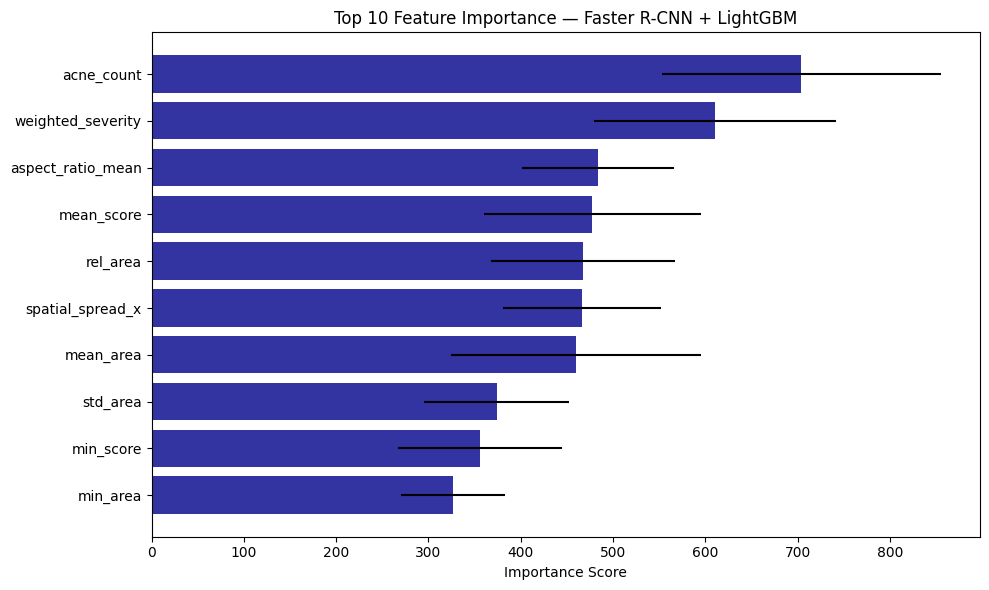

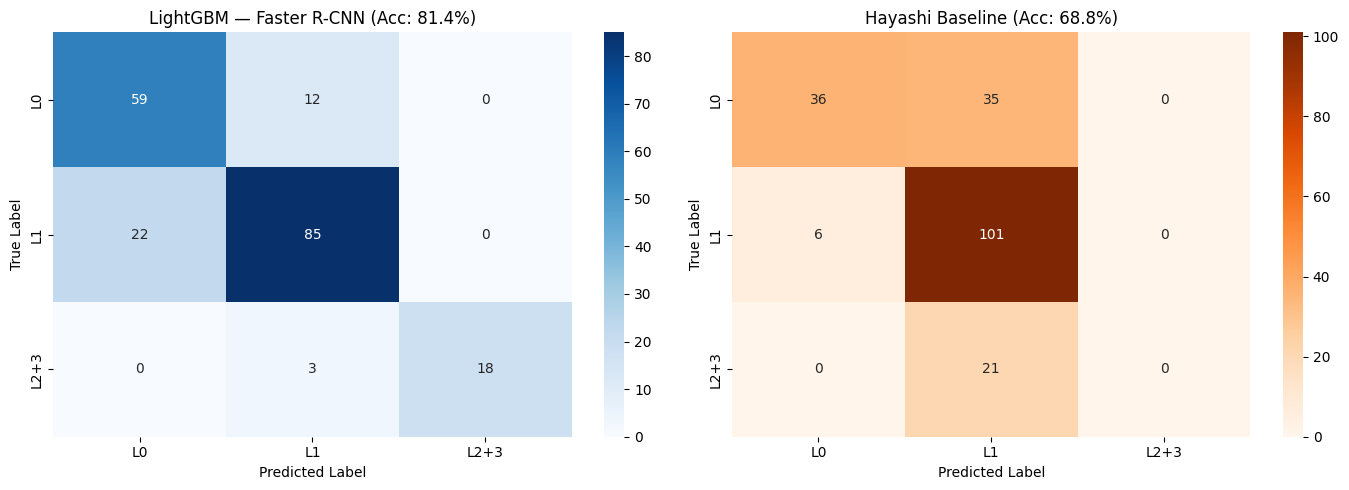

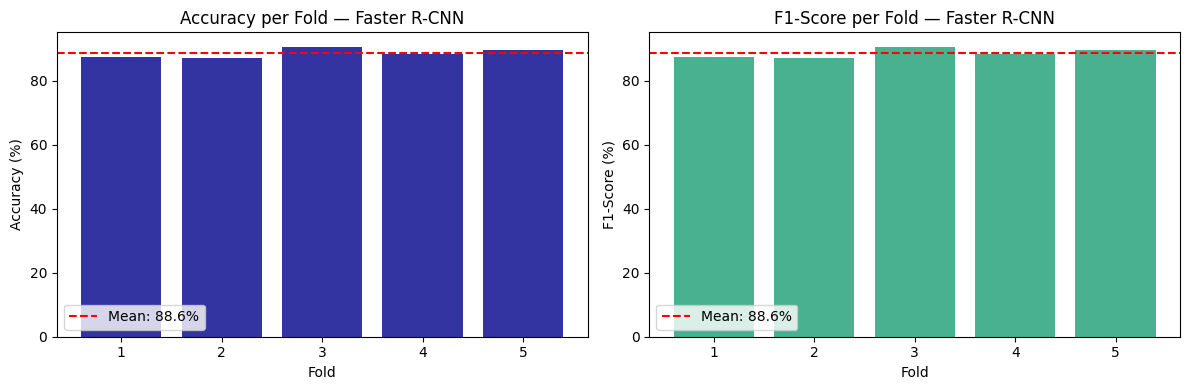


 CLASSIFICATION COMPLETE — Faster R-CNN + LightGBM
 Accuracy : 81.41%
 F1-Score : 81.60%
 Results  : /content/drive/MyDrive/yolo_acne_detection/results/classification_frcnn

OVR MACRO-AVERAGING METRICS — Faster R-CNN (3-class merged)

 LightGBM (Faster R-CNN features) — 3-class merged

Class              TP    TN    FP    FN     Pre      Sn      Sp      F1      YI
  ---------------------------------------------------------------------------
  Level 0          59   106    22    12  0.7284  0.8310  0.8281  0.7763  0.6591
  Level 1          85    77    15    22  0.8500  0.7944  0.8370  0.8213  0.6313
  Level 2+3        18   178     0     3  1.0000  0.8571  1.0000  0.9231  0.8571
  ---------------------------------------------------------------------------
  Macro Avg                              0.8595  0.8275  0.8884  0.8402  0.7159

  Overall Accuracy : 81.41%

 Hayashi Baseline — 3-class merged

Class              TP    TN    FP    FN     Pre      Sn      Sp      F1      YI
  --------

In [ ]:
import re
import random
import numpy as np
import pandas as pd
import lightgbm as lgb
from pathlib import Path
from PIL import Image
from torchvision.models.detection import fasterrcnn_resnet50_fpn_v2
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection.rpn import AnchorGenerator
from torchvision.transforms import v2
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, f1_score
from sklearn.model_selection import StratifiedKFold
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import json
from tqdm import tqdm
import torch
import torch.nn as nn

# ── Seed ──────────────────────────────────────────────────
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False
    print(f" Global seed set to: {seed}")

set_seed(42)

# ── Paths ─────────────────────────────────────────────────
BASE_DIR    = Path('/content/drive/MyDrive/yolo_acne_detection')
TRAIN_DIR   = BASE_DIR / 'dataset_frcnn' / 'train'
VAL_DIR     = BASE_DIR / 'dataset_frcnn' / 'val'
TEST_DIR    = BASE_DIR / 'dataset_frcnn' / 'test'
TRAIN_IMG   = BASE_DIR / 'dataset' / 'train' / 'images'
VAL_IMG     = BASE_DIR / 'JPEGImages_640'
TEST_IMG    = BASE_DIR / 'JPEGImages_640'
CKPT_PATH   = BASE_DIR / 'checkpoints_frcnn' / 'best_model_frcnn.pth'
RESULTS_DIR = BASE_DIR / 'results' / 'classification_frcnn'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

MEAN = [0.45815152, 0.361242,  0.29348266]
STD  = [0.2814769,  0.226306,  0.20132513]

# ── Settings ──────────────────────────────────────────────
SCORE_THRESHOLD = 0.1
MAX_DETECTIONS  = 250
DEVICE          = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f"  Device          : {DEVICE}")
print(f"  Score threshold : {SCORE_THRESHOLD}")

LEVEL_NAMES = {0: 'Mild', 1: 'Moderate', 2: 'Severe', 3: 'Very Severe'}

# ══════════════════════════════════════════════════════════
# 1. LOAD FASTER R-CNN
# ══════════════════════════════════════════════════════════
def build_model(num_classes=2, dropout=0.3):
    model = fasterrcnn_resnet50_fpn_v2(weights=None)

    anchor_generator = AnchorGenerator(
        sizes=((17,), (24,), (30,), (37,), (49,)),
        aspect_ratios=((0.77, 1.29, 2.08),) * 5
    )
    model.rpn.anchor_generator   = anchor_generator
    model.rpn.nms_thresh          = 0.3
    model.roi_heads.nms_thresh    = 0.3
    model.roi_heads.score_thresh  = SCORE_THRESHOLD
    model.roi_heads.detections_per_img = MAX_DETECTIONS

    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

    model.roi_heads.box_head[5] = nn.Sequential(
        model.roi_heads.box_head[5],
        nn.Dropout(p=dropout)
    )
    return model

print(f"\n Loading Faster R-CNN model...")
model      = build_model()
checkpoint = torch.load(CKPT_PATH, map_location=DEVICE)
model.load_state_dict(checkpoint['model_state_dict'])
model.to(DEVICE)
model.eval()
print(f" Model loaded from epoch {checkpoint['epoch']+1} "
      f"(val_loss: {checkpoint['val_loss']:.4f})")

# ══════════════════════════════════════════════════════════
# 2. HELPERS
# ══════════════════════════════════════════════════════════
def get_level(filename):
    match = re.search(r'levle(\d)', filename.lower())
    return int(match.group(1)) if match else None

# YENİ - DOĞRU
def merge_levels(labels):
    result = labels.copy()
    result[labels == 2] = 1  # L2 → L1+2
    result[labels == 3] = 2  # L3 → 2
    return result

def hayashi_grade(count):
    if count <= 5:    return 0
    elif count <= 50: return 1  # L1+L2 merged
    else:             return 2  # L3

inference_transform = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=MEAN, std=STD),
])

# ══════════════════════════════════════════════════════════
# 3. FEATURE EXTRACTION
# ══════════════════════════════════════════════════════════
def extract_features(img_path):
    try:
        img          = Image.open(img_path).convert('RGB')
        img_w, img_h = img.size
        img_area     = img_w * img_h
    except Exception as e:
        print(f"  Error loading {img_path}: {e}")
        return None

    img_tensor = inference_transform(img).to(DEVICE)

    with torch.no_grad():
        outputs = model([img_tensor])[0]

    boxes  = outputs['boxes'].cpu().numpy()
    scores = outputs['scores'].cpu().numpy()
    count  = len(boxes)

    if count == 0:
        return {
            'acne_count'        : 0,
            'weighted_severity' : 0.0,
            'density'           : 0.0,
            'mean_area'         : 0.0,
            'std_area'          : 0.0,
            'min_area'          : 0.0,
            'max_area'          : 0.0,
            'rel_area'          : 0.0,
            'spatial_spread_x'  : 0.0,
            'spatial_spread_y'  : 0.0,
            'aspect_ratio_mean' : 0.0,
            'aspect_ratio_std'  : 0.0,
            'mean_score'        : 0.0,
            'max_score'         : 0.0,
            'min_score'         : 0.0,
            'std_score'         : 0.0,
        }

    widths        = boxes[:, 2] - boxes[:, 0]
    heights       = boxes[:, 3] - boxes[:, 1]
    areas         = widths * heights
    aspect_ratios = widths / (heights + 1e-6)
    cx            = (boxes[:, 0] + boxes[:, 2]) / 2
    cy            = (boxes[:, 1] + boxes[:, 3]) / 2

    weighted_sum      = np.sum(scores * (areas / img_area))
    weighted_severity = (200 / np.pi) * np.arctan(20 * weighted_sum)

    return {
        'acne_count'        : count,
        'weighted_severity' : float(weighted_severity),
        'density'           : count / (img_area / 1_000_000),
        'mean_area'         : float(np.mean(areas)),
        'std_area'          : float(np.std(areas)),
        'min_area'          : float(np.min(areas)),
        'max_area'          : float(np.max(areas)),
        'rel_area'          : float(np.sum(areas) / img_area),
        'spatial_spread_x'  : float(np.std(cx)) if count > 1 else 0.0,
        'spatial_spread_y'  : float(np.std(cy)) if count > 1 else 0.0,
        'aspect_ratio_mean' : float(np.mean(aspect_ratios)),
        'aspect_ratio_std'  : float(np.std(aspect_ratios)),
        'mean_score'        : float(np.mean(scores)),
        'max_score'         : float(np.max(scores)),
        'min_score'         : float(np.min(scores)),
        'std_score'         : float(np.std(scores)),
    }

# ══════════════════════════════════════════════════════════
# 4. PROCESS SPLIT
# ══════════════════════════════════════════════════════════
def process_split(ann_path, images_dir, split_name):
    with open(ann_path) as f:
        coco = json.load(f)

    features  = []
    labels    = []
    hayashi   = []
    filenames = []
    skipped   = 0

    print(f"\n Processing {split_name} ({len(coco['images'])} images)...")

    for img_info in tqdm(coco['images'], desc=split_name):
        filename = img_info['file_name']
        img_path = Path(images_dir) / filename
        level    = get_level(filename)

        if level is None:
            skipped += 1
            continue
        if not img_path.exists():
            skipped += 1
            continue

        feat = extract_features(img_path)
        if feat is None:
            skipped += 1
            continue

        features.append(feat)
        labels.append(level)
        hayashi.append(hayashi_grade(feat['acne_count']))
        filenames.append(filename)

    print(f"   Processed: {len(features)} images, {skipped} skipped")
    return (
        pd.DataFrame(features),
        np.array(labels),
        np.array(hayashi),
        np.array(filenames)
    )

# ══════════════════════════════════════════════════════════
# 5. FEATURE EXTRACTION
# ══════════════════════════════════════════════════════════
print("\n" + "=" * 70)
print("🔍 FEATURE EXTRACTION")
print("=" * 70)

X_train, y_train, h_train, f_train = process_split(
    TRAIN_DIR / 'annotations_coco.json', TRAIN_IMG, 'train')
X_val,   y_val,   h_val,   f_val   = process_split(
    VAL_DIR   / 'annotations_coco.json', VAL_IMG,   'val')
X_test,  y_test,  h_test,  f_test  = process_split(
    TEST_DIR  / 'annotations_coco.json', TEST_IMG,  'test')

y_train_merged = merge_levels(y_train)
y_val_merged   = merge_levels(y_val)
y_test_merged  = merge_levels(y_test)
h_test_merged  = merge_levels(h_test)

X_train_full = pd.concat([X_train, X_val], ignore_index=True)
y_train_full = np.concatenate([y_train_merged, y_val_merged])

print(f"\n Dataset sizes:")
print(f"  Train+Val : {len(X_train_full)} images")
print(f"  Test      : {len(X_test)} images")

print(f"\n Box count stats (test):")
print(f"  Total boxes    : {X_test['acne_count'].sum()}")
print(f"  Mean per image : {X_test['acne_count'].mean():.1f}")
print(f"  Images with 0  : {(X_test['acne_count'] == 0).sum()}/{len(X_test)}")

print(f"\n Label distribution (test, merged):")
for lvl, name in [(0, 'Level 0'), (1, 'Level 1'), (2, 'Level 2+3')]:
    count = np.sum(y_test_merged == lvl)
    pct   = count / len(y_test_merged) * 100
    print(f"  {name}: {count:4d} ({pct:.1f}%)")

# ══════════════════════════════════════════════════════════
# 6. LIGHTGBM
# ══════════════════════════════════════════════════════════
print("\n" + "=" * 70)
print(" LIGHTGBM — 5-Fold Stratified CV + Early Stopping")
print("=" * 70)

N_FOLDS        = 5
skf            = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)
test_preds_all = np.zeros((len(X_test), 3))
fold_models    = []
fold_scores    = []
feature_names  = list(X_train_full.columns)

for fold, (train_idx, val_idx) in enumerate(skf.split(X_train_full, y_train_full)):
    print(f"\n  📂 Fold {fold+1}/{N_FOLDS}")

    X_fold_train = X_train_full.iloc[train_idx]
    y_fold_train = y_train_full[train_idx]
    X_fold_val   = X_train_full.iloc[val_idx]
    y_fold_val   = y_train_full[val_idx]

    lgbm_fold = lgb.LGBMClassifier(
        n_estimators     = 200,
        learning_rate    = 0.05,
        max_depth        = 6,
        num_leaves       = 31,
        min_child_samples= 5,
        subsample        = 0.8,
        colsample_bytree = 0.8,
        class_weight     = 'balanced',
        random_state     = 42,
        verbose          = -1,
        n_jobs           = -1,
    )

    lgbm_fold.fit(
        X_fold_train, y_fold_train,
        eval_set = [(X_fold_val, y_fold_val)],
        callbacks= [lgb.early_stopping(30, verbose=False),
                    lgb.log_evaluation(period=-1)],
    )

    print(f"    Best iteration : {lgbm_fold.best_iteration_}")
    test_preds_all += lgbm_fold.predict_proba(X_test) / N_FOLDS

    fold_pred = lgbm_fold.predict(X_fold_val)
    fold_acc  = accuracy_score(y_fold_val, fold_pred)
    fold_f1   = f1_score(y_fold_val, fold_pred, average='weighted')
    fold_scores.append({'acc': fold_acc, 'f1': fold_f1})
    fold_models.append(lgbm_fold)

    print(f"    Fold Accuracy  : {fold_acc*100:.2f}%")
    print(f"    Fold F1-Score  : {fold_f1*100:.2f}%")

print(f"\n Cross-Validation Summary:")
print(f"  Mean Accuracy : {np.mean([s['acc'] for s in fold_scores])*100:.2f}%"
      f" ± {np.std([s['acc'] for s in fold_scores])*100:.2f}%")
print(f"  Mean F1-Score : {np.mean([s['f1'] for s in fold_scores])*100:.2f}%"
      f" ± {np.std([s['f1'] for s in fold_scores])*100:.2f}%")

y_pred       = np.argmax(test_preds_all, axis=1)
y_pred_proba = test_preds_all

# ══════════════════════════════════════════════════════════
# 7. RESULTS
# ══════════════════════════════════════════════════════════
print("\n" + "=" * 70)
print(" FINAL RESULTS")
print("=" * 70)

acc_lgbm = accuracy_score(y_test_merged, y_pred)
f1_lgbm  = f1_score(y_test_merged, y_pred, average='weighted')

print(f"\n LightGBM Ensemble (Faster R-CNN features)")
print(f"  Accuracy : {acc_lgbm*100:.2f}%")
print(f"  F1-Score : {f1_lgbm*100:.2f}%")
print(f"\n{classification_report(y_test_merged, y_pred, target_names=['Level 0','Level 1','Level 2+3'], digits=4)}")

acc_hayashi = accuracy_score(y_test_merged, h_test_merged)
f1_hayashi  = f1_score(y_test_merged, h_test_merged, average='weighted')

print(f"\n Hayashi Baseline")
print(f"  Accuracy : {acc_hayashi*100:.2f}%")
print(f"  F1-Score : {f1_hayashi*100:.2f}%")

print(f"\n Improvement over Hayashi:")
print(f"  Accuracy : +{(acc_lgbm - acc_hayashi)*100:.2f}%")
print(f"  F1-Score : +{(f1_lgbm  - f1_hayashi)*100:.2f}%")

# ══════════════════════════════════════════════════════════
# 8. VISUALIZATIONS
# ══════════════════════════════════════════════════════════
importance_matrix = np.array([m.feature_importances_ for m in fold_models])
importance_df     = pd.DataFrame({
    'feature'   : feature_names,
    'importance': importance_matrix.mean(axis=0),
    'std'       : importance_matrix.std(axis=0),
}).sort_values('importance', ascending=False)

print(f"\n📊 Top 10 Important Features:")
print(importance_df.head(10).to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 6))
top_f = importance_df.head(10)
ax.barh(top_f['feature'], top_f['importance'],
        xerr=top_f['std'], color='#00008B', alpha=0.8)
ax.set_xlabel('Importance Score')
ax.set_title('Top 10 Feature Importance — Faster R-CNN + LightGBM')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'feature_importance_frcnn.png', dpi=300, bbox_inches='tight')
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cm_lgbm = confusion_matrix(y_test_merged, y_pred)
sns.heatmap(cm_lgbm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['L0','L1','L2+3'],
            yticklabels=['L0','L1','L2+3'])
axes[0].set_title(f'LightGBM — Faster R-CNN (Acc: {acc_lgbm*100:.1f}%)')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

cm_hayashi = confusion_matrix(y_test_merged, h_test_merged)
sns.heatmap(cm_hayashi, annot=True, fmt='d', cmap='Oranges', ax=axes[1],
            xticklabels=['L0','L1','L2+3'],
            yticklabels=['L0','L1','L2+3'])
axes[1].set_title(f'Hayashi Baseline (Acc: {acc_hayashi*100:.1f}%)')
axes[1].set_ylabel('True Label')
axes[1].set_xlabel('Predicted Label')

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'confusion_matrices_frcnn.png', dpi=300, bbox_inches='tight')
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fold_accs = [s['acc']*100 for s in fold_scores]
fold_f1s  = [s['f1']*100  for s in fold_scores]

axes[0].bar(range(1, N_FOLDS+1), fold_accs, color='#00008B', alpha=0.8)
axes[0].axhline(np.mean(fold_accs), color='red', linestyle='--',
                label=f'Mean: {np.mean(fold_accs):.1f}%')
axes[0].set_title('Accuracy per Fold — Faster R-CNN')
axes[0].set_xlabel('Fold')
axes[0].set_ylabel('Accuracy (%)')
axes[0].legend()

axes[1].bar(range(1, N_FOLDS+1), fold_f1s, color='#1D9E75', alpha=0.8)
axes[1].axhline(np.mean(fold_f1s), color='red', linestyle='--',
                label=f'Mean: {np.mean(fold_f1s):.1f}%')
axes[1].set_title('F1-Score per Fold — Faster R-CNN')
axes[1].set_xlabel('Fold')
axes[1].set_ylabel('F1-Score (%)')
axes[1].legend()

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'cv_fold_scores_frcnn.png', dpi=300, bbox_inches='tight')
plt.show()

# ══════════════════════════════════════════════════════════
# 9. SAVE
# ══════════════════════════════════════════════════════════
with open(RESULTS_DIR / 'lgbm_ensemble_frcnn.pkl', 'wb') as f:
    pickle.dump(fold_models, f)

metadata = {
    'detection_model' : 'Faster R-CNN ResNet50 FPN v2',
    'features'        : feature_names,
    'classes'         : ['Level 0', 'Level 1', 'Level 2+3'],
    'accuracy'        : float(acc_lgbm),
    'f1_score'        : float(f1_lgbm),
    'cv_mean_acc'     : float(np.mean([s['acc'] for s in fold_scores])),
    'cv_std_acc'      : float(np.std([s['acc']  for s in fold_scores])),
    'cv_mean_f1'      : float(np.mean([s['f1']  for s in fold_scores])),
    'cv_std_f1'       : float(np.std([s['f1']   for s in fold_scores])),
    'train_samples'   : len(X_train_full),
    'test_samples'    : len(X_test),
    'score_threshold' : SCORE_THRESHOLD,
    'n_folds'         : N_FOLDS,
}
with open(RESULTS_DIR / 'metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

predictions_df = pd.DataFrame({
    'filename'         : f_test,
    'true_level'       : y_test,
    'true_level_merged': y_test_merged,
    'pred_level'       : y_pred,
    'hayashi_level'    : h_test_merged,
    'confidence'       : np.max(y_pred_proba, axis=1),
})
predictions_df.to_csv(RESULTS_DIR / 'predictions_frcnn.csv', index=False)

print("\n" + "=" * 70)
print(" CLASSIFICATION COMPLETE — Faster R-CNN + LightGBM")
print("=" * 70)
print(f" Accuracy : {acc_lgbm*100:.2f}%")
print(f" F1-Score : {f1_lgbm*100:.2f}%")
print(f" Results  : {RESULTS_DIR}")
print("=" * 70)

# ══════════════════════════════════════════════════════════
# 10. OVR MACRO-AVERAGING METRICS — FRCNN
# ══════════════════════════════════════════════════════════
print("\n" + "=" * 70)
print("OVR MACRO-AVERAGING METRICS — Faster R-CNN (3-class merged)")
print("=" * 70)

CLASS_LABELS_FRCNN = ['Level 0', 'Level 1', 'Level 2+3']

def compute_ovr_metrics(y_true, y_pred, class_labels):
    n_classes = len(class_labels)
    cm        = confusion_matrix(y_true, y_pred)
    per_class = []

    print(f"\n{'Class':<15} {'TP':>5} {'TN':>5} {'FP':>5} {'FN':>5} "
          f"{'Pre':>7} {'Sn':>7} {'Sp':>7} {'F1':>7} {'YI':>7}")
    print("  " + "-" * 75)

    for i in range(n_classes):
        TP = cm[i, i]
        FN = cm[i, :].sum() - TP
        FP = cm[:, i].sum() - TP
        TN = cm.sum() - TP - FN - FP

        Pre = TP / (TP + FP) if (TP + FP) > 0 else 0.0
        Sn  = TP / (TP + FN) if (TP + FN) > 0 else 0.0
        Sp  = TN / (TN + FP) if (TN + FP) > 0 else 0.0
        F1  = 2 * Pre * Sn / (Pre + Sn) if (Pre + Sn) > 0 else 0.0
        YI  = Sn + Sp - 1

        per_class.append({
            'class': class_labels[i],
            'TP': TP, 'TN': TN, 'FP': FP, 'FN': FN,
            'Pre': Pre, 'Sn': Sn, 'Sp': Sp, 'F1': F1, 'YI': YI,
        })

        print(f"  {class_labels[i]:<13} {TP:>5} {TN:>5} {FP:>5} {FN:>5} "
              f"{Pre:>7.4f} {Sn:>7.4f} {Sp:>7.4f} {F1:>7.4f} {YI:>7.4f}")

    macro_pre = np.mean([r['Pre'] for r in per_class])
    macro_sn  = np.mean([r['Sn']  for r in per_class])
    macro_sp  = np.mean([r['Sp']  for r in per_class])
    macro_f1  = np.mean([r['F1']  for r in per_class])
    macro_yi  = np.mean([r['YI']  for r in per_class])
    overall_acc = accuracy_score(y_true, y_pred)

    print("  " + "-" * 75)
    print(f"  {'Macro Avg':<13} {'':>5} {'':>5} {'':>5} {'':>5} "
          f"{macro_pre:>7.4f} {macro_sn:>7.4f} {macro_sp:>7.4f} "
          f"{macro_f1:>7.4f} {macro_yi:>7.4f}")
    print(f"\n  Overall Accuracy : {overall_acc*100:.2f}%")

    return {
        'per_class' : per_class,
        'macro_pre' : macro_pre,
        'macro_sn'  : macro_sn,
        'macro_sp'  : macro_sp,
        'macro_f1'  : macro_f1,
        'macro_yi'  : macro_yi,
        'accuracy'  : overall_acc,
    }

# ── LightGBM ──────────────────────────────────────────────
print("\n LightGBM (Faster R-CNN features) — 3-class merged")
frcnn_lgbm_metrics = compute_ovr_metrics(
    y_test_merged, y_pred, CLASS_LABELS_FRCNN)

# ── Hayashi ───────────────────────────────────────────────
print("\n Hayashi Baseline — 3-class merged")
frcnn_hayashi_metrics = compute_ovr_metrics(
    y_test_merged, h_test_merged, CLASS_LABELS_FRCNN)

# ── Summary ───────────────────────────────────────────────
print("\n" + "=" * 70)
print(" SUMMARY — LightGBM vs Hayashi (Faster R-CNN)")
print("=" * 70)
print(f"\n{'Metric':<12} {'LightGBM':>10} {'Hayashi':>10} {'Δ':>10}")
print("  " + "-" * 42)
for label, key in [
    ('Accuracy',    'accuracy'),
    ('Precision',   'macro_pre'),
    ('Sensitivity', 'macro_sn'),
    ('Specificity', 'macro_sp'),
    ('F1-Score',    'macro_f1'),
    ('Youden',      'macro_yi'),
]:
    lgbm_val    = frcnn_lgbm_metrics[key]
    hayashi_val = frcnn_hayashi_metrics[key]
    delta       = lgbm_val - hayashi_val
    print(f"  {label:<12} {lgbm_val*100:>9.2f}% "
          f"{hayashi_val*100:>9.2f}% {delta*100:>+9.2f}%")

# ── Save CSV ──────────────────────────────────────────────
rows = []
for r in frcnn_lgbm_metrics['per_class']:
    rows.append({
        'model'      : 'LightGBM_FRCNN_3class',
        'class'      : r['class'],
        'TP': r['TP'], 'TN': r['TN'], 'FP': r['FP'], 'FN': r['FN'],
        'Precision'  : round(r['Pre'], 4),
        'Sensitivity': round(r['Sn'],  4),
        'Specificity': round(r['Sp'],  4),
        'F1'         : round(r['F1'],  4),
        'Youden'     : round(r['YI'],  4),
    })
for r in frcnn_hayashi_metrics['per_class']:
    rows.append({
        'model'      : 'Hayashi_FRCNN_3class',
        'class'      : r['class'],
        'TP': r['TP'], 'TN': r['TN'], 'FP': r['FP'], 'FN': r['FN'],
        'Precision'  : round(r['Pre'], 4),
        'Sensitivity': round(r['Sn'],  4),
        'Specificity': round(r['Sp'],  4),
        'F1'         : round(r['F1'],  4),
        'Youden'     : round(r['YI'],  4),
    })

pd.DataFrame(rows).to_csv(
    RESULTS_DIR / 'ovr_metrics_frcnn_3class.csv', index=False)

# ── Save probabilities ────────────────────────────────────
np.save(RESULTS_DIR / 'y_pred_proba_frcnn.npy', y_pred_proba)
np.save(RESULTS_DIR / 'y_test_merged_frcnn.npy', y_test_merged)
np.save(RESULTS_DIR / 'y_pred_frcnn.npy', y_pred)

print(f"\n All saved to: {RESULTS_DIR}")

Global seed set to: 42
  Device          : cuda
  Score threshold : 0.1

Loading Faster R-CNN model...
Model loaded from epoch 11 (val_loss: 0.3126)

FEATURE EXTRACTION

Processing train (1345 images)...


train: 100%|██████████| 1345/1345 [03:21<00:00,  6.68it/s]


  Processed: 1345 images, 0 skipped

Processing val (198 images)...


val: 100%|██████████| 198/198 [02:31<00:00,  1.31it/s]


  Processed: 198 images, 0 skipped

Processing test (199 images)...


test: 100%|██████████| 199/199 [02:30<00:00,  1.32it/s]


  Processed: 199 images, 0 skipped

Dataset sizes:
  Train+Val : 1543 images
  Test      : 199 images

Box count stats (test):
  Total boxes    : 5970
  Mean per image : 30.0
  Images with 0  : 2/199

Label distribution (test, L1+L2 merged):
  Level 0 (Mild):   71 (35.7%)
  Level 1+2 (Mod+Sev):  107 (53.8%)
  Level 3 (V.Severe):   21 (10.6%)

LIGHTGBM — 5-Fold Stratified CV + Early Stopping

  Fold 1/5
    Best iteration : 54
    Fold Accuracy  : 87.38%
    Fold F1-Score  : 87.50%

  Fold 2/5
    Best iteration : 76
    Fold Accuracy  : 87.06%
    Fold F1-Score  : 87.07%

  Fold 3/5
    Best iteration : 95
    Fold Accuracy  : 90.61%
    Fold F1-Score  : 90.69%

  Fold 4/5
    Best iteration : 74
    Fold Accuracy  : 88.31%
    Fold F1-Score  : 88.37%

  Fold 5/5
    Best iteration : 56
    Fold Accuracy  : 89.61%
    Fold F1-Score  : 89.57%

Cross-Validation Summary:
  Mean Accuracy : 88.59% +/- 1.34%
  Mean F1-Score : 88.64% +/- 1.33%

FINAL RESULTS — L0 / L1+2 / L3

LightGBM Ensembl

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


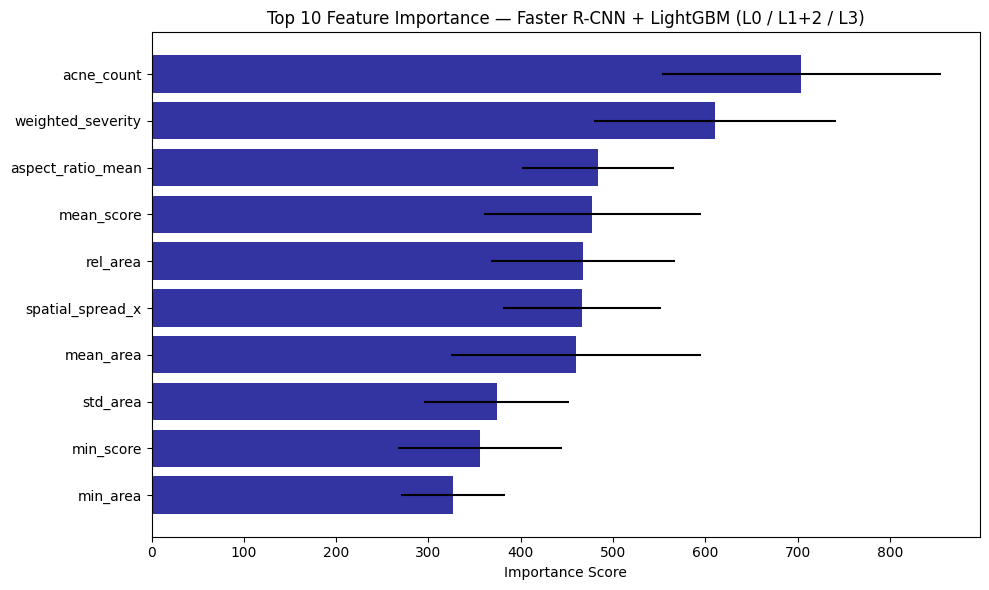

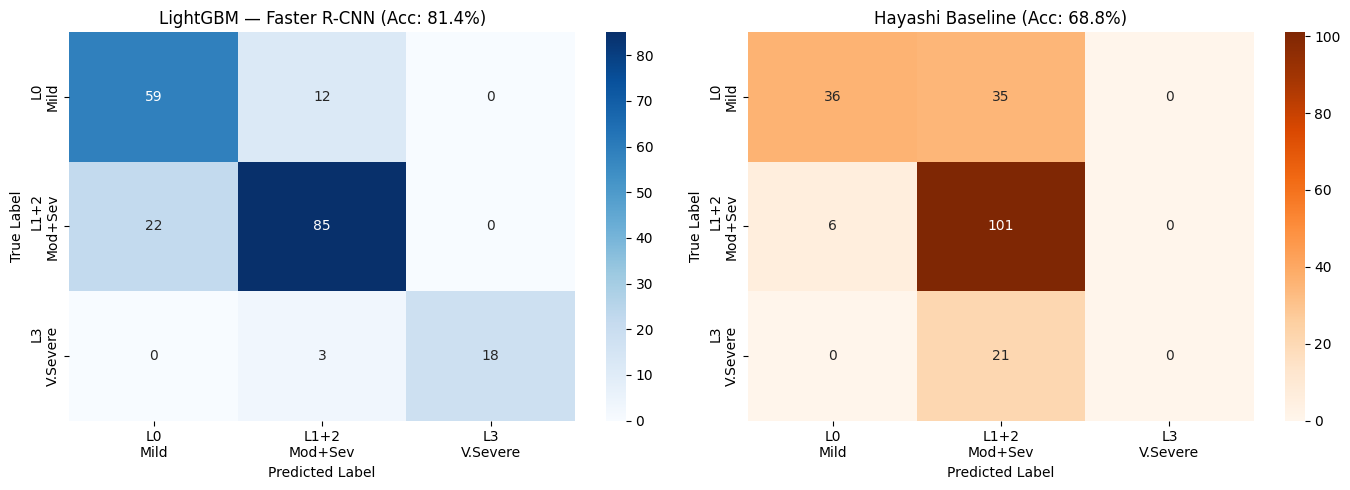

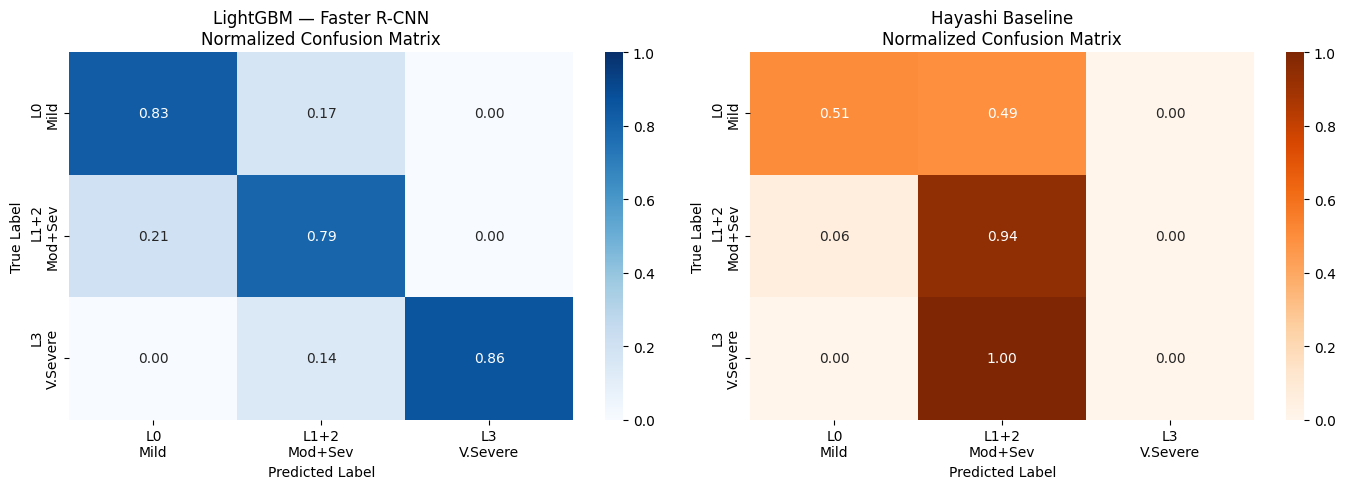

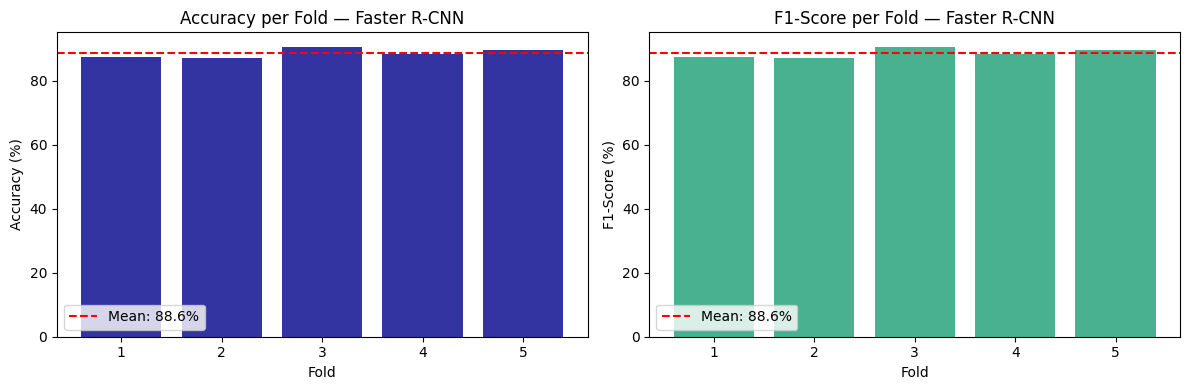


CLASSIFICATION COMPLETE — Faster R-CNN + LightGBM (L0 / L1+2 / L3)
  Accuracy : 81.41%
  F1-Score : 81.60%
  Results  : /content/drive/MyDrive/yolo_acne_detection/results/classification_frcnn

OVR MACRO-AVERAGING METRICS — Faster R-CNN (L0 / L1+2 / L3)

LightGBM (Faster R-CNN features) — L0 / L1+2 / L3

Class              TP    TN    FP    FN     Pre      Sn      Sp      F1      YI
  ---------------------------------------------------------------------------
  Level 0          59   106    22    12  0.7284  0.8310  0.8281  0.7763  0.6591
  Level 1+2        85    77    15    22  0.8500  0.7944  0.8370  0.8213  0.6313
  Level 3          18   178     0     3  1.0000  0.8571  1.0000  0.9231  0.8571
  ---------------------------------------------------------------------------
  Macro Avg                              0.8595  0.8275  0.8884  0.8402  0.7159

  Overall Accuracy : 81.41%

Hayashi Baseline — L0 / L1+2 / L3

Class              TP    TN    FP    FN     Pre      Sn      Sp      F1  

In [ ]:
import re
import random
import numpy as np
import pandas as pd
import lightgbm as lgb
from pathlib import Path
from PIL import Image
from torchvision.models.detection import fasterrcnn_resnet50_fpn_v2
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection.rpn import AnchorGenerator
from torchvision.transforms import v2
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, f1_score
from sklearn.model_selection import StratifiedKFold
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import json
from tqdm import tqdm
import torch
import torch.nn as nn

# ── Seed ──────────────────────────────────────────────────
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False
    print(f"Global seed set to: {seed}")

set_seed(42)

# ── Paths ─────────────────────────────────────────────────
BASE_DIR    = Path('/content/drive/MyDrive/yolo_acne_detection')
TRAIN_DIR   = BASE_DIR / 'dataset_frcnn' / 'train'
VAL_DIR     = BASE_DIR / 'dataset_frcnn' / 'val'
TEST_DIR    = BASE_DIR / 'dataset_frcnn' / 'test'
TRAIN_IMG   = BASE_DIR / 'dataset' / 'train' / 'images'
VAL_IMG     = BASE_DIR / 'JPEGImages_640'
TEST_IMG    = BASE_DIR / 'JPEGImages_640'
CKPT_PATH   = BASE_DIR / 'checkpoints_frcnn' / 'best_model_frcnn.pth'
RESULTS_DIR = BASE_DIR / 'results' / 'classification_frcnn'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

MEAN = [0.45815152, 0.361242,  0.29348266]
STD  = [0.2814769,  0.226306,  0.20132513]

# ── Settings ──────────────────────────────────────────────
SCORE_THRESHOLD = 0.1
MAX_DETECTIONS  = 250
DEVICE          = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f"  Device          : {DEVICE}")
print(f"  Score threshold : {SCORE_THRESHOLD}")

# ── Classes: L0, L1+2, L3 (L1 and L2 merged) ─────────────
CLASS_LABELS = ['Level 0', 'Level 1+2', 'Level 3']

# ══════════════════════════════════════════════════════════
# 1. LOAD FASTER R-CNN
# ══════════════════════════════════════════════════════════
def build_model(num_classes=2, dropout=0.3):
    model = fasterrcnn_resnet50_fpn_v2(weights=None)

    anchor_generator = AnchorGenerator(
        sizes=((17,), (24,), (30,), (37,), (49,)),
        aspect_ratios=((0.77, 1.29, 2.08),) * 5
    )
    model.rpn.anchor_generator        = anchor_generator
    model.rpn.nms_thresh               = 0.3
    model.roi_heads.nms_thresh         = 0.3
    model.roi_heads.score_thresh       = SCORE_THRESHOLD
    model.roi_heads.detections_per_img = MAX_DETECTIONS

    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

    model.roi_heads.box_head[5] = nn.Sequential(
        model.roi_heads.box_head[5],
        nn.Dropout(p=dropout)
    )
    return model

print(f"\nLoading Faster R-CNN model...")
model      = build_model()
checkpoint = torch.load(CKPT_PATH, map_location=DEVICE)
model.load_state_dict(checkpoint['model_state_dict'])
model.to(DEVICE)
model.eval()
print(f"Model loaded from epoch {checkpoint['epoch']+1} "
      f"(val_loss: {checkpoint['val_loss']:.4f})")

# ══════════════════════════════════════════════════════════
# 2. HELPERS
# ══════════════════════════════════════════════════════════
def get_level(filename):
    match = re.search(r'levle(\d)', filename.lower())
    return int(match.group(1)) if match else None

def merge_levels(labels):
    """Merge L1 and L2 into a single class (L1+2).
    L0 -> 0, L1 -> 1, L2 -> 1, L3 -> 2
    """
    result = labels.copy()
    result[labels == 2] = 1  # L2 -> L1+2
    result[labels == 3] = 2  # L3 -> class 2
    return result

def hayashi_grade(count):
    """Hayashi rule-based grading under 3-class merged scheme.
    0-5   -> L0 (class 0)
    6-50  -> L1+2 (class 1, merged)
    >50   -> L3 (class 2)
    """
    if count <= 5:    return 0
    elif count <= 50: return 1  # L1+2 merged
    else:             return 2  # L3

inference_transform = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=MEAN, std=STD),
])

# ══════════════════════════════════════════════════════════
# 3. FEATURE EXTRACTION
# ══════════════════════════════════════════════════════════
def extract_features(img_path):
    try:
        img          = Image.open(img_path).convert('RGB')
        img_w, img_h = img.size
        img_area     = img_w * img_h
    except Exception as e:
        print(f"Error loading {img_path}: {e}")
        return None

    img_tensor = inference_transform(img).to(DEVICE)

    with torch.no_grad():
        outputs = model([img_tensor])[0]

    boxes  = outputs['boxes'].cpu().numpy()
    scores = outputs['scores'].cpu().numpy()
    count  = len(boxes)

    if count == 0:
        return {
            'acne_count'        : 0,
            'weighted_severity' : 0.0,
            'density'           : 0.0,
            'mean_area'         : 0.0,
            'std_area'          : 0.0,
            'min_area'          : 0.0,
            'max_area'          : 0.0,
            'rel_area'          : 0.0,
            'spatial_spread_x'  : 0.0,
            'spatial_spread_y'  : 0.0,
            'aspect_ratio_mean' : 0.0,
            'aspect_ratio_std'  : 0.0,
            'mean_score'        : 0.0,
            'max_score'         : 0.0,
            'min_score'         : 0.0,
            'std_score'         : 0.0,
        }

    widths        = boxes[:, 2] - boxes[:, 0]
    heights       = boxes[:, 3] - boxes[:, 1]
    areas         = widths * heights
    aspect_ratios = widths / (heights + 1e-6)
    cx            = (boxes[:, 0] + boxes[:, 2]) / 2
    cy            = (boxes[:, 1] + boxes[:, 3]) / 2

    weighted_sum      = np.sum(scores * (areas / img_area))
    weighted_severity = (200 / np.pi) * np.arctan(20 * weighted_sum)

    return {
        'acne_count'        : count,
        'weighted_severity' : float(weighted_severity),
        'density'           : count / (img_area / 1_000_000),
        'mean_area'         : float(np.mean(areas)),
        'std_area'          : float(np.std(areas)),
        'min_area'          : float(np.min(areas)),
        'max_area'          : float(np.max(areas)),
        'rel_area'          : float(np.sum(areas) / img_area),
        'spatial_spread_x'  : float(np.std(cx)) if count > 1 else 0.0,
        'spatial_spread_y'  : float(np.std(cy)) if count > 1 else 0.0,
        'aspect_ratio_mean' : float(np.mean(aspect_ratios)),
        'aspect_ratio_std'  : float(np.std(aspect_ratios)),
        'mean_score'        : float(np.mean(scores)),
        'max_score'         : float(np.max(scores)),
        'min_score'         : float(np.min(scores)),
        'std_score'         : float(np.std(scores)),
    }

# ══════════════════════════════════════════════════════════
# 4. PROCESS SPLIT
# ══════════════════════════════════════════════════════════
def process_split(ann_path, images_dir, split_name):
    with open(ann_path) as f:
        coco = json.load(f)

    features  = []
    labels    = []
    hayashi   = []
    filenames = []
    skipped   = 0

    print(f"\nProcessing {split_name} ({len(coco['images'])} images)...")

    for img_info in tqdm(coco['images'], desc=split_name):
        filename = img_info['file_name']
        img_path = Path(images_dir) / filename
        level    = get_level(filename)

        if level is None:
            skipped += 1
            continue
        if not img_path.exists():
            skipped += 1
            continue

        feat = extract_features(img_path)
        if feat is None:
            skipped += 1
            continue

        features.append(feat)
        labels.append(level)
        hayashi.append(hayashi_grade(feat['acne_count']))
        filenames.append(filename)

    print(f"  Processed: {len(features)} images, {skipped} skipped")
    return (
        pd.DataFrame(features),
        np.array(labels),
        np.array(hayashi),
        np.array(filenames)
    )

# ══════════════════════════════════════════════════════════
# 5. FEATURE EXTRACTION
# ══════════════════════════════════════════════════════════
print("\n" + "=" * 70)
print("FEATURE EXTRACTION")
print("=" * 70)

X_train, y_train, h_train, f_train = process_split(
    TRAIN_DIR / 'annotations_coco.json', TRAIN_IMG, 'train')
X_val,   y_val,   h_val,   f_val   = process_split(
    VAL_DIR   / 'annotations_coco.json', VAL_IMG,   'val')
X_test,  y_test,  h_test,  f_test  = process_split(
    TEST_DIR  / 'annotations_coco.json', TEST_IMG,  'test')

# Merge L1+L2 -> class 1, L3 -> class 2
y_train_merged = merge_levels(y_train)
y_val_merged   = merge_levels(y_val)
y_test_merged  = merge_levels(y_test)
h_test_merged  = merge_levels(h_test)

X_train_full = pd.concat([X_train, X_val], ignore_index=True)
y_train_full = np.concatenate([y_train_merged, y_val_merged])

print(f"\nDataset sizes:")
print(f"  Train+Val : {len(X_train_full)} images")
print(f"  Test      : {len(X_test)} images")

print(f"\nBox count stats (test):")
print(f"  Total boxes    : {X_test['acne_count'].sum()}")
print(f"  Mean per image : {X_test['acne_count'].mean():.1f}")
print(f"  Images with 0  : {(X_test['acne_count'] == 0).sum()}/{len(X_test)}")

print(f"\nLabel distribution (test, L1+L2 merged):")
for lvl, name in [(0, 'Level 0 (Mild)'), (1, 'Level 1+2 (Mod+Sev)'), (2, 'Level 3 (V.Severe)')]:
    count = np.sum(y_test_merged == lvl)
    pct   = count / len(y_test_merged) * 100
    print(f"  {name}: {count:4d} ({pct:.1f}%)")

# ══════════════════════════════════════════════════════════
# 6. LIGHTGBM
# ══════════════════════════════════════════════════════════
print("\n" + "=" * 70)
print("LIGHTGBM — 5-Fold Stratified CV + Early Stopping")
print("=" * 70)

N_FOLDS        = 5
skf            = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)
test_preds_all = np.zeros((len(X_test), 3))
fold_models    = []
fold_scores    = []
feature_names  = list(X_train_full.columns)

for fold, (train_idx, val_idx) in enumerate(skf.split(X_train_full, y_train_full)):
    print(f"\n  Fold {fold+1}/{N_FOLDS}")

    X_fold_train = X_train_full.iloc[train_idx]
    y_fold_train = y_train_full[train_idx]
    X_fold_val   = X_train_full.iloc[val_idx]
    y_fold_val   = y_train_full[val_idx]

    lgbm_fold = lgb.LGBMClassifier(
        n_estimators     = 200,
        learning_rate    = 0.05,
        max_depth        = 6,
        num_leaves       = 31,
        min_child_samples= 5,
        subsample        = 0.8,
        colsample_bytree = 0.8,
        class_weight     = 'balanced',
        random_state     = 42,
        verbose          = -1,
        n_jobs           = -1,
    )

    lgbm_fold.fit(
        X_fold_train, y_fold_train,
        eval_set = [(X_fold_val, y_fold_val)],
        callbacks= [lgb.early_stopping(30, verbose=False),
                    lgb.log_evaluation(period=-1)],
    )

    print(f"    Best iteration : {lgbm_fold.best_iteration_}")
    test_preds_all += lgbm_fold.predict_proba(X_test) / N_FOLDS

    fold_pred = lgbm_fold.predict(X_fold_val)
    fold_acc  = accuracy_score(y_fold_val, fold_pred)
    fold_f1   = f1_score(y_fold_val, fold_pred, average='weighted')
    fold_scores.append({'acc': fold_acc, 'f1': fold_f1})
    fold_models.append(lgbm_fold)

    print(f"    Fold Accuracy  : {fold_acc*100:.2f}%")
    print(f"    Fold F1-Score  : {fold_f1*100:.2f}%")

print(f"\nCross-Validation Summary:")
print(f"  Mean Accuracy : {np.mean([s['acc'] for s in fold_scores])*100:.2f}%"
      f" +/- {np.std([s['acc'] for s in fold_scores])*100:.2f}%")
print(f"  Mean F1-Score : {np.mean([s['f1'] for s in fold_scores])*100:.2f}%"
      f" +/- {np.std([s['f1'] for s in fold_scores])*100:.2f}%")

y_pred       = np.argmax(test_preds_all, axis=1)
y_pred_proba = test_preds_all

# ══════════════════════════════════════════════════════════
# 7. RESULTS
# ══════════════════════════════════════════════════════════
print("\n" + "=" * 70)
print("FINAL RESULTS — L0 / L1+2 / L3")
print("=" * 70)

acc_lgbm = accuracy_score(y_test_merged, y_pred)
f1_lgbm  = f1_score(y_test_merged, y_pred, average='weighted')

print(f"\nLightGBM Ensemble (Faster R-CNN features)")
print(f"  Accuracy : {acc_lgbm*100:.2f}%")
print(f"  F1-Score : {f1_lgbm*100:.2f}%")
print(f"\n{classification_report(y_test_merged, y_pred, target_names=CLASS_LABELS, digits=4)}")

acc_hayashi = accuracy_score(y_test_merged, h_test_merged)
f1_hayashi  = f1_score(y_test_merged, h_test_merged, average='weighted')

print(f"\nHayashi Baseline")
print(f"  Accuracy : {acc_hayashi*100:.2f}%")
print(f"  F1-Score : {f1_hayashi*100:.2f}%")
print(f"\n{classification_report(y_test_merged, h_test_merged, target_names=CLASS_LABELS, digits=4)}")

print(f"\nImprovement over Hayashi:")
print(f"  Accuracy : +{(acc_lgbm - acc_hayashi)*100:.2f}%")
print(f"  F1-Score : +{(f1_lgbm  - f1_hayashi)*100:.2f}%")

# ══════════════════════════════════════════════════════════
# 8. VISUALIZATIONS
# ══════════════════════════════════════════════════════════
importance_matrix = np.array([m.feature_importances_ for m in fold_models])
importance_df     = pd.DataFrame({
    'feature'   : feature_names,
    'importance': importance_matrix.mean(axis=0),
    'std'       : importance_matrix.std(axis=0),
}).sort_values('importance', ascending=False)

print(f"\nTop 10 Important Features:")
print(importance_df.head(10).to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 6))
top_f = importance_df.head(10)
ax.barh(top_f['feature'], top_f['importance'],
        xerr=top_f['std'], color='#00008B', alpha=0.8)
ax.set_xlabel('Importance Score')
ax.set_title('Top 10 Feature Importance — Faster R-CNN + LightGBM (L0 / L1+2 / L3)')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'feature_importance_frcnn.png', dpi=300, bbox_inches='tight')
plt.show()

tick_labels = ['L0\nMild', 'L1+2\nMod+Sev', 'L3\nV.Severe']

cm_lgbm    = confusion_matrix(y_test_merged, y_pred)
cm_hayashi = confusion_matrix(y_test_merged, h_test_merged)

cm_lgbm_norm    = cm_lgbm.astype(float) / cm_lgbm.sum(axis=1, keepdims=True)
cm_hayashi_norm = cm_hayashi.astype(float) / cm_hayashi.sum(axis=1, keepdims=True)
cm_lgbm_norm    = np.nan_to_num(cm_lgbm_norm)
cm_hayashi_norm = np.nan_to_num(cm_hayashi_norm)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(cm_lgbm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=tick_labels, yticklabels=tick_labels)
axes[0].set_title(f'LightGBM — Faster R-CNN (Acc: {acc_lgbm*100:.1f}%)')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

sns.heatmap(cm_hayashi, annot=True, fmt='d', cmap='Oranges', ax=axes[1],
            xticklabels=tick_labels, yticklabels=tick_labels)
axes[1].set_title(f'Hayashi Baseline (Acc: {acc_hayashi*100:.1f}%)')
axes[1].set_ylabel('True Label')
axes[1].set_xlabel('Predicted Label')

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'confusion_matrices_frcnn.png', dpi=300, bbox_inches='tight')
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(cm_lgbm_norm, annot=True, fmt='.2f', cmap='Blues', ax=axes[0],
            xticklabels=tick_labels, yticklabels=tick_labels, vmin=0, vmax=1)
axes[0].set_title('LightGBM — Faster R-CNN\nNormalized Confusion Matrix')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

sns.heatmap(cm_hayashi_norm, annot=True, fmt='.2f', cmap='Oranges', ax=axes[1],
            xticklabels=tick_labels, yticklabels=tick_labels, vmin=0, vmax=1)
axes[1].set_title('Hayashi Baseline\nNormalized Confusion Matrix')
axes[1].set_ylabel('True Label')
axes[1].set_xlabel('Predicted Label')

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'confusion_matrices_frcnn_normalized.png', dpi=300, bbox_inches='tight')
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fold_accs = [s['acc']*100 for s in fold_scores]
fold_f1s  = [s['f1']*100  for s in fold_scores]

axes[0].bar(range(1, N_FOLDS+1), fold_accs, color='#00008B', alpha=0.8)
axes[0].axhline(np.mean(fold_accs), color='red', linestyle='--',
                label=f'Mean: {np.mean(fold_accs):.1f}%')
axes[0].set_title('Accuracy per Fold — Faster R-CNN')
axes[0].set_xlabel('Fold')
axes[0].set_ylabel('Accuracy (%)')
axes[0].legend()

axes[1].bar(range(1, N_FOLDS+1), fold_f1s, color='#1D9E75', alpha=0.8)
axes[1].axhline(np.mean(fold_f1s), color='red', linestyle='--',
                label=f'Mean: {np.mean(fold_f1s):.1f}%')
axes[1].set_title('F1-Score per Fold — Faster R-CNN')
axes[1].set_xlabel('Fold')
axes[1].set_ylabel('F1-Score (%)')
axes[1].legend()

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'cv_fold_scores_frcnn.png', dpi=300, bbox_inches='tight')
plt.show()

# ══════════════════════════════════════════════════════════
# 9. SAVE
# ══════════════════════════════════════════════════════════
with open(RESULTS_DIR / 'lgbm_ensemble_frcnn.pkl', 'wb') as f:
    pickle.dump(fold_models, f)

metadata = {
    'detection_model' : 'Faster R-CNN ResNet50 FPN v2',
    'features'        : feature_names,
    'classes'         : CLASS_LABELS,
    'merge_scheme'    : 'L1+L2 -> class 1 (L1+2), L3 -> class 2',
    'accuracy'        : float(acc_lgbm),
    'f1_score'        : float(f1_lgbm),
    'cv_mean_acc'     : float(np.mean([s['acc'] for s in fold_scores])),
    'cv_std_acc'      : float(np.std([s['acc']  for s in fold_scores])),
    'cv_mean_f1'      : float(np.mean([s['f1']  for s in fold_scores])),
    'cv_std_f1'       : float(np.std([s['f1']   for s in fold_scores])),
    'train_samples'   : len(X_train_full),
    'test_samples'    : len(X_test),
    'score_threshold' : SCORE_THRESHOLD,
    'n_folds'         : N_FOLDS,
}
with open(RESULTS_DIR / 'metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

predictions_df = pd.DataFrame({
    'filename'         : f_test,
    'true_level'       : y_test,
    'true_level_merged': y_test_merged,
    'pred_level'       : y_pred,
    'hayashi_level'    : h_test_merged,
    'confidence'       : np.max(y_pred_proba, axis=1),
})
predictions_df.to_csv(RESULTS_DIR / 'predictions_frcnn.csv', index=False)

print("\n" + "=" * 70)
print("CLASSIFICATION COMPLETE — Faster R-CNN + LightGBM (L0 / L1+2 / L3)")
print("=" * 70)
print(f"  Accuracy : {acc_lgbm*100:.2f}%")
print(f"  F1-Score : {f1_lgbm*100:.2f}%")
print(f"  Results  : {RESULTS_DIR}")
print("=" * 70)

# ══════════════════════════════════════════════════════════
# 10. OVR MACRO-AVERAGING METRICS
# ══════════════════════════════════════════════════════════
print("\n" + "=" * 70)
print("OVR MACRO-AVERAGING METRICS — Faster R-CNN (L0 / L1+2 / L3)")
print("=" * 70)

def compute_ovr_metrics(y_true, y_pred, class_labels):
    cm        = confusion_matrix(y_true, y_pred)
    per_class = []

    print(f"\n{'Class':<15} {'TP':>5} {'TN':>5} {'FP':>5} {'FN':>5} "
          f"{'Pre':>7} {'Sn':>7} {'Sp':>7} {'F1':>7} {'YI':>7}")
    print("  " + "-" * 75)

    for i in range(len(class_labels)):
        TP = cm[i, i]
        FN = cm[i, :].sum() - TP
        FP = cm[:, i].sum() - TP
        TN = cm.sum() - TP - FN - FP

        Pre = TP / (TP + FP) if (TP + FP) > 0 else 0.0
        Sn  = TP / (TP + FN) if (TP + FN) > 0 else 0.0
        Sp  = TN / (TN + FP) if (TN + FP) > 0 else 0.0
        F1  = 2 * Pre * Sn / (Pre + Sn) if (Pre + Sn) > 0 else 0.0
        YI  = Sn + Sp - 1

        per_class.append({
            'class': class_labels[i],
            'TP': TP, 'TN': TN, 'FP': FP, 'FN': FN,
            'Pre': Pre, 'Sn': Sn, 'Sp': Sp, 'F1': F1, 'YI': YI,
        })

        print(f"  {class_labels[i]:<13} {TP:>5} {TN:>5} {FP:>5} {FN:>5} "
              f"{Pre:>7.4f} {Sn:>7.4f} {Sp:>7.4f} {F1:>7.4f} {YI:>7.4f}")

    macro_pre = np.mean([r['Pre'] for r in per_class])
    macro_sn  = np.mean([r['Sn']  for r in per_class])
    macro_sp  = np.mean([r['Sp']  for r in per_class])
    macro_f1  = np.mean([r['F1']  for r in per_class])
    macro_yi  = np.mean([r['YI']  for r in per_class])
    overall_acc = accuracy_score(y_true, y_pred)

    print("  " + "-" * 75)
    print(f"  {'Macro Avg':<13} {'':>5} {'':>5} {'':>5} {'':>5} "
          f"{macro_pre:>7.4f} {macro_sn:>7.4f} {macro_sp:>7.4f} "
          f"{macro_f1:>7.4f} {macro_yi:>7.4f}")
    print(f"\n  Overall Accuracy : {overall_acc*100:.2f}%")

    return {
        'per_class' : per_class,
        'macro_pre' : macro_pre,
        'macro_sn'  : macro_sn,
        'macro_sp'  : macro_sp,
        'macro_f1'  : macro_f1,
        'macro_yi'  : macro_yi,
        'accuracy'  : overall_acc,
    }

print("\nLightGBM (Faster R-CNN features) — L0 / L1+2 / L3")
frcnn_lgbm_metrics = compute_ovr_metrics(y_test_merged, y_pred, CLASS_LABELS)

print("\nHayashi Baseline — L0 / L1+2 / L3")
frcnn_hayashi_metrics = compute_ovr_metrics(y_test_merged, h_test_merged, CLASS_LABELS)

print("\n" + "=" * 70)
print("SUMMARY — LightGBM vs Hayashi (Faster R-CNN, L0 / L1+2 / L3)")
print("=" * 70)
print(f"\n{'Metric':<12} {'LightGBM':>10} {'Hayashi':>10} {'Delta':>10}")
print("  " + "-" * 42)
for label, key in [
    ('Accuracy',    'accuracy'),
    ('Precision',   'macro_pre'),
    ('Sensitivity', 'macro_sn'),
    ('Specificity', 'macro_sp'),
    ('F1-Score',    'macro_f1'),
    ('Youden',      'macro_yi'),
]:
    lgbm_val    = frcnn_lgbm_metrics[key]
    hayashi_val = frcnn_hayashi_metrics[key]
    delta       = lgbm_val - hayashi_val
    print(f"  {label:<12} {lgbm_val*100:>9.2f}% "
          f"{hayashi_val*100:>9.2f}% {delta*100:>+9.2f}%")

rows = []
for r in frcnn_lgbm_metrics['per_class']:
    rows.append({
        'model'      : 'LightGBM_FRCNN_L0_L1+2_L3',
        'class'      : r['class'],
        'TP': r['TP'], 'TN': r['TN'], 'FP': r['FP'], 'FN': r['FN'],
        'Precision'  : round(r['Pre'], 4),
        'Sensitivity': round(r['Sn'],  4),
        'Specificity': round(r['Sp'],  4),
        'F1'         : round(r['F1'],  4),
        'Youden'     : round(r['YI'],  4),
    })
for r in frcnn_hayashi_metrics['per_class']:
    rows.append({
        'model'      : 'Hayashi_FRCNN_L0_L1+2_L3',
        'class'      : r['class'],
        'TP': r['TP'], 'TN': r['TN'], 'FP': r['FP'], 'FN': r['FN'],
        'Precision'  : round(r['Pre'], 4),
        'Sensitivity': round(r['Sn'],  4),
        'Specificity': round(r['Sp'],  4),
        'F1'         : round(r['F1'],  4),
        'Youden'     : round(r['YI'],  4),
    })

pd.DataFrame(rows).to_csv(
    RESULTS_DIR / 'ovr_metrics_frcnn_L0_L1+2_L3.csv', index=False)

np.save(RESULTS_DIR / 'y_pred_proba_frcnn.npy', y_pred_proba)
np.save(RESULTS_DIR / 'y_test_merged_frcnn.npy', y_test_merged)
np.save(RESULTS_DIR / 'y_pred_frcnn.npy', y_pred)

print(f"\nAll saved to: {RESULTS_DIR}")


Global seed set to: 42
  Device          : cuda
  Score threshold : 0.1

Loading Faster R-CNN model...
Model loaded from epoch 11 (val_loss: 0.3126)

FEATURE EXTRACTION

Processing train (1345 images)...


train: 100%|██████████| 1345/1345 [03:09<00:00,  7.10it/s]


  Processed: 1345 images, 0 skipped

Processing val (198 images)...


val: 100%|██████████| 198/198 [00:28<00:00,  6.93it/s]


  Processed: 198 images, 0 skipped

Processing test (199 images)...


test: 100%|██████████| 199/199 [00:29<00:00,  6.74it/s]


  Processed: 199 images, 0 skipped

Dataset sizes:
  Train+Val : 1543 images
  Test      : 199 images

Label distribution (test, four class):
  Level 0:   71 (35.7%)
  Level 1:   87 (43.7%)
  Level 2:   20 (10.1%)
  Level 3:   21 (10.6%)

LIGHTGBM — 5-Fold Stratified CV + Early Stopping

  Fold 1/5
    Best iteration : 49
    Fold Accuracy  : 82.20%
    Fold F1-Score  : 82.10%

  Fold 2/5
    Best iteration : 72
    Fold Accuracy  : 85.44%
    Fold F1-Score  : 85.50%

  Fold 3/5
    Best iteration : 53
    Fold Accuracy  : 83.82%
    Fold F1-Score  : 83.57%

  Fold 4/5
    Best iteration : 63
    Fold Accuracy  : 85.06%
    Fold F1-Score  : 85.06%

  Fold 5/5
    Best iteration : 57
    Fold Accuracy  : 80.52%
    Fold F1-Score  : 80.53%

Cross-Validation Summary:
  Mean Accuracy : 83.41% +/- 1.83%
  Mean F1-Score : 83.35% +/- 1.85%

FINAL RESULTS — 4 Classes (Level 0 / Level 1 / Level 2 / Level 3)

LightGBM Ensemble (Faster R-CNN features)
  Accuracy : 72.36%
  F1-Score : 72.78%

    

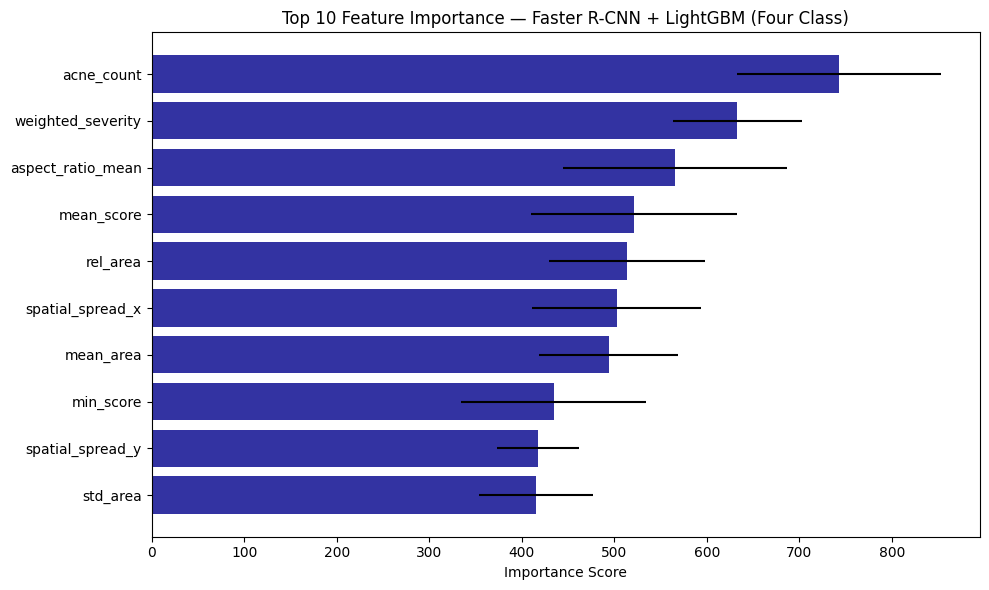

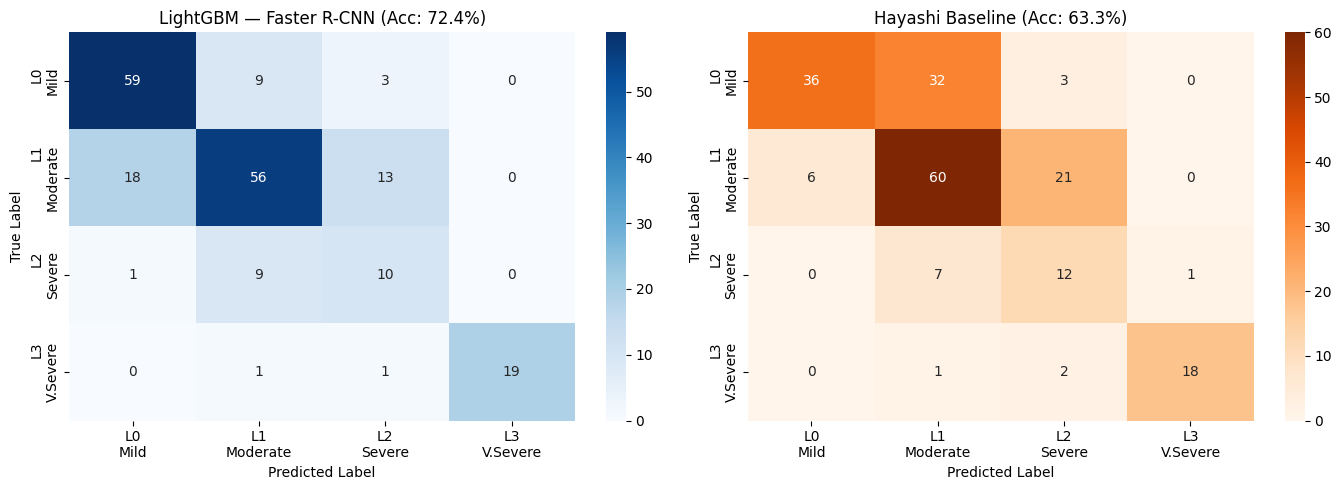

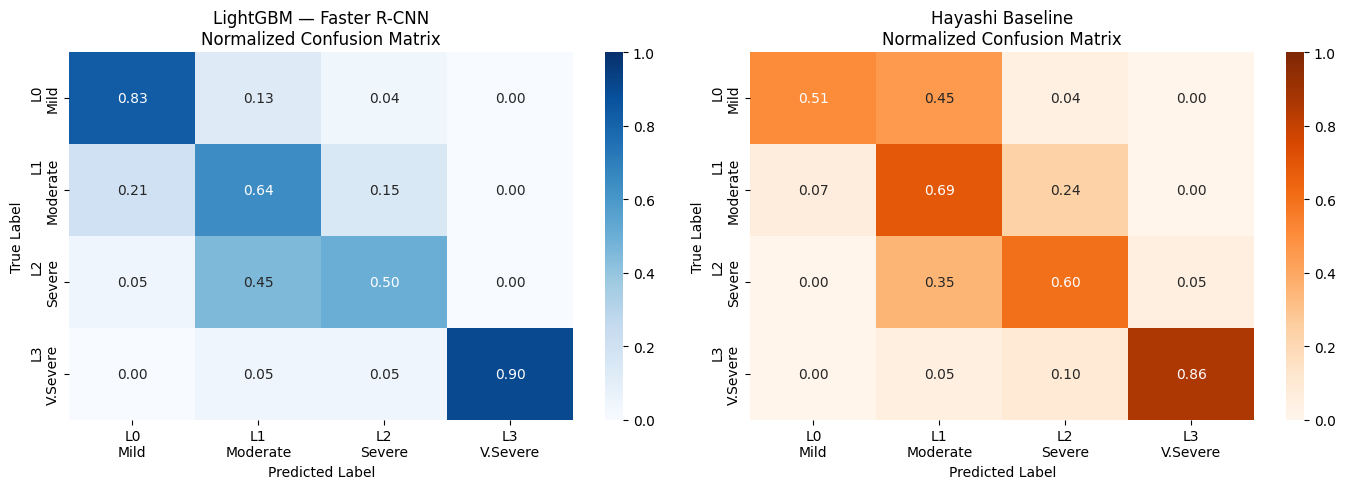

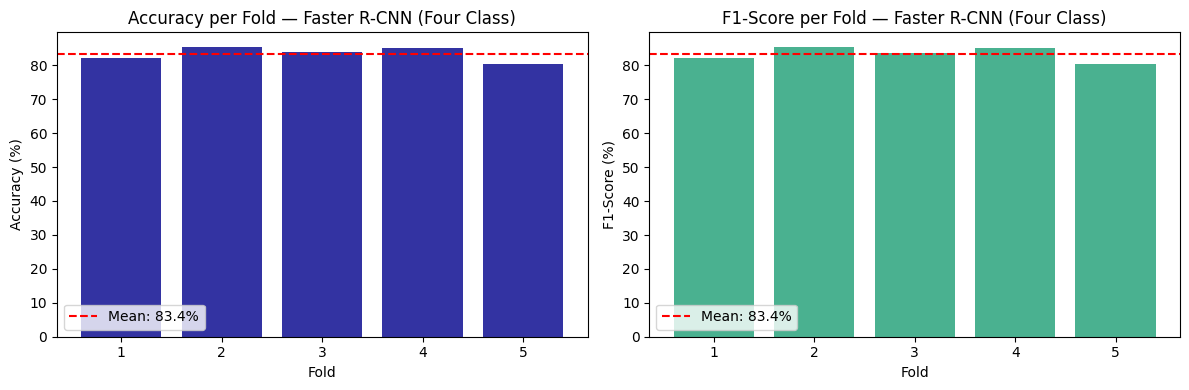


CLASSIFICATION COMPLETE — Faster R-CNN + LightGBM (Four Class)
  Accuracy : 72.36%
  F1-Score : 72.78%
  Results  : /content/drive/MyDrive/yolo_acne_detection/results/classification_frcnn_four_class

OVR MACRO-AVERAGING METRICS — Faster R-CNN (Four Class)

LightGBM (Faster R-CNN features) — Four Class

Class              TP    TN    FP    FN     Pre      Sn      Sp      F1      YI
  ---------------------------------------------------------------------------
  Level 0          59   109    19    12  0.7564  0.8310  0.8516  0.7919  0.6825
  Level 1          56    93    19    31  0.7467  0.6437  0.8304  0.6914  0.4740
  Level 2          10   162    17    10  0.3704  0.5000  0.9050  0.4255  0.4050
  Level 3          19   178     0     2  1.0000  0.9048  1.0000  0.9500  0.9048
  ---------------------------------------------------------------------------
  Macro Avg                              0.7184  0.7199  0.8967  0.7147  0.6166

  Overall Accuracy : 72.36%

Hayashi Baseline — Four Class

In [ ]:
import re
import random
import numpy as np
import pandas as pd
import lightgbm as lgb
from pathlib import Path
from PIL import Image
from torchvision.models.detection import fasterrcnn_resnet50_fpn_v2
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection.rpn import AnchorGenerator
from torchvision.transforms import v2
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, f1_score
from sklearn.model_selection import StratifiedKFold
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import json
from tqdm import tqdm
import torch
import torch.nn as nn

# ── Seed ──────────────────────────────────────────────────
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False
    print(f"Global seed set to: {seed}")

set_seed(42)

# ── Paths ──────────────────────────────────────────────────
BASE_DIR    = Path('/content/drive/MyDrive/yolo_acne_detection')
TRAIN_DIR   = BASE_DIR / 'dataset_frcnn' / 'train'
VAL_DIR     = BASE_DIR / 'dataset_frcnn' / 'val'
TEST_DIR    = BASE_DIR / 'dataset_frcnn' / 'test'
TRAIN_IMG   = BASE_DIR / 'dataset' / 'train' / 'images'
VAL_IMG     = BASE_DIR / 'JPEGImages_640'
TEST_IMG    = BASE_DIR / 'JPEGImages_640'
CKPT_PATH   = BASE_DIR / 'checkpoints_frcnn' / 'best_model_frcnn.pth'
RESULTS_DIR = BASE_DIR / 'results' / 'classification_frcnn_four_class'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

MEAN = [0.45815152, 0.361242,  0.29348266]
STD  = [0.2814769,  0.226306,  0.20132513]

# ── Settings ───────────────────────────────────────────────
SCORE_THRESHOLD = 0.1
MAX_DETECTIONS  = 250
DEVICE          = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f"  Device          : {DEVICE}")
print(f"  Score threshold : {SCORE_THRESHOLD}")

# ── Classes: L0, L1, L2, L3 (no merging) ──────────────────
CLASS_LABELS = ['Level 0', 'Level 1', 'Level 2', 'Level 3']
N_CLASSES    = 4

# ══════════════════════════════════════════════════════════
# 1. LOAD FASTER R-CNN
# ══════════════════════════════════════════════════════════
def build_model(num_classes=2, dropout=0.3):
    model = fasterrcnn_resnet50_fpn_v2(weights=None)

    anchor_generator = AnchorGenerator(
        sizes=((17,), (24,), (30,), (37,), (49,)),
        aspect_ratios=((0.77, 1.29, 2.08),) * 5
    )
    model.rpn.anchor_generator        = anchor_generator
    model.rpn.nms_thresh               = 0.3
    model.roi_heads.nms_thresh         = 0.3
    model.roi_heads.score_thresh       = SCORE_THRESHOLD
    model.roi_heads.detections_per_img = MAX_DETECTIONS

    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

    model.roi_heads.box_head[5] = nn.Sequential(
        model.roi_heads.box_head[5],
        nn.Dropout(p=dropout)
    )
    return model

print(f"\nLoading Faster R-CNN model...")
model      = build_model()
checkpoint = torch.load(CKPT_PATH, map_location=DEVICE)
model.load_state_dict(checkpoint['model_state_dict'])
model.to(DEVICE)
model.eval()
print(f"Model loaded from epoch {checkpoint['epoch']+1} "
      f"(val_loss: {checkpoint['val_loss']:.4f})")

# ══════════════════════════════════════════════════════════
# 2. HELPERS
# ══════════════════════════════════════════════════════════
def get_level(filename):
    match = re.search(r'levle(\d)', filename.lower())
    return int(match.group(1)) if match else None

def hayashi_grade(count):
    if count <= 5:    return 0
    elif count <= 20: return 1
    elif count <= 50: return 2
    else:             return 3

inference_transform = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=MEAN, std=STD),
])

# ══════════════════════════════════════════════════════════
# 3. FEATURE EXTRACTION
# ══════════════════════════════════════════════════════════
def extract_features(img_path):
    try:
        img          = Image.open(img_path).convert('RGB')
        img_w, img_h = img.size
        img_area     = img_w * img_h
    except Exception as e:
        print(f"Error loading {img_path}: {e}")
        return None

    img_tensor = inference_transform(img).to(DEVICE)

    with torch.no_grad():
        outputs = model([img_tensor])[0]

    boxes  = outputs['boxes'].cpu().numpy()
    scores = outputs['scores'].cpu().numpy()
    count  = len(boxes)

    if count == 0:
        return {
            'acne_count'        : 0,
            'weighted_severity' : 0.0,
            'density'           : 0.0,
            'mean_area'         : 0.0,
            'std_area'          : 0.0,
            'min_area'          : 0.0,
            'max_area'          : 0.0,
            'rel_area'          : 0.0,
            'spatial_spread_x'  : 0.0,
            'spatial_spread_y'  : 0.0,
            'aspect_ratio_mean' : 0.0,
            'aspect_ratio_std'  : 0.0,
            'mean_score'        : 0.0,
            'max_score'         : 0.0,
            'min_score'         : 0.0,
            'std_score'         : 0.0,
        }

    widths        = boxes[:, 2] - boxes[:, 0]
    heights       = boxes[:, 3] - boxes[:, 1]
    areas         = widths * heights
    aspect_ratios = widths / (heights + 1e-6)
    cx            = (boxes[:, 0] + boxes[:, 2]) / 2
    cy            = (boxes[:, 1] + boxes[:, 3]) / 2

    weighted_sum      = np.sum(scores * (areas / img_area))
    weighted_severity = (200 / np.pi) * np.arctan(20 * weighted_sum)

    return {
        'acne_count'        : count,
        'weighted_severity' : float(weighted_severity),
        'density'           : count / (img_area / 1_000_000),
        'mean_area'         : float(np.mean(areas)),
        'std_area'          : float(np.std(areas)),
        'min_area'          : float(np.min(areas)),
        'max_area'          : float(np.max(areas)),
        'rel_area'          : float(np.sum(areas) / img_area),
        'spatial_spread_x'  : float(np.std(cx)) if count > 1 else 0.0,
        'spatial_spread_y'  : float(np.std(cy)) if count > 1 else 0.0,
        'aspect_ratio_mean' : float(np.mean(aspect_ratios)),
        'aspect_ratio_std'  : float(np.std(aspect_ratios)),
        'mean_score'        : float(np.mean(scores)),
        'max_score'         : float(np.max(scores)),
        'min_score'         : float(np.min(scores)),
        'std_score'         : float(np.std(scores)),
    }

# ══════════════════════════════════════════════════════════
# 4. PROCESS SPLIT
# ══════════════════════════════════════════════════════════
def process_split(ann_path, images_dir, split_name):
    with open(ann_path) as f:
        coco = json.load(f)

    features  = []
    labels    = []
    hayashi   = []
    filenames = []
    skipped   = 0

    print(f"\nProcessing {split_name} ({len(coco['images'])} images)...")

    for img_info in tqdm(coco['images'], desc=split_name):
        filename = img_info['file_name']
        img_path = Path(images_dir) / filename
        level    = get_level(filename)

        if level is None:
            skipped += 1
            continue
        if not img_path.exists():
            skipped += 1
            continue

        feat = extract_features(img_path)
        if feat is None:
            skipped += 1
            continue

        features.append(feat)
        labels.append(level)
        hayashi.append(hayashi_grade(feat['acne_count']))
        filenames.append(filename)

    print(f"  Processed: {len(features)} images, {skipped} skipped")
    return (
        pd.DataFrame(features),
        np.array(labels),
        np.array(hayashi),
        np.array(filenames)
    )

# ══════════════════════════════════════════════════════════
# 5. FEATURE EXTRACTION
# ══════════════════════════════════════════════════════════
print("\n" + "=" * 70)
print("FEATURE EXTRACTION")
print("=" * 70)

X_train, y_train, h_train, f_train = process_split(
    TRAIN_DIR / 'annotations_coco.json', TRAIN_IMG, 'train')
X_val,   y_val,   h_val,   f_val   = process_split(
    VAL_DIR   / 'annotations_coco.json', VAL_IMG,   'val')
X_test,  y_test,  h_test,  f_test  = process_split(
    TEST_DIR  / 'annotations_coco.json', TEST_IMG,  'test')

X_train_full = pd.concat([X_train, X_val], ignore_index=True)
y_train_full = np.concatenate([y_train, y_val])

print(f"\nDataset sizes:")
print(f"  Train+Val : {len(X_train_full)} images")
print(f"  Test      : {len(X_test)} images")

print(f"\nLabel distribution (test, four class):")
for lvl, name in enumerate(CLASS_LABELS):
    count = np.sum(y_test == lvl)
    pct   = count / len(y_test) * 100
    print(f"  {name}: {count:4d} ({pct:.1f}%)")

# ══════════════════════════════════════════════════════════
# 6. LIGHTGBM
# ══════════════════════════════════════════════════════════
print("\n" + "=" * 70)
print("LIGHTGBM — 5-Fold Stratified CV + Early Stopping")
print("=" * 70)

N_FOLDS        = 5
skf            = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)
test_preds_all = np.zeros((len(X_test), N_CLASSES))
fold_models    = []
fold_scores    = []
feature_names  = list(X_train_full.columns)

for fold, (train_idx, val_idx) in enumerate(skf.split(X_train_full, y_train_full)):
    print(f"\n  Fold {fold+1}/{N_FOLDS}")

    X_fold_train = X_train_full.iloc[train_idx]
    y_fold_train = y_train_full[train_idx]
    X_fold_val   = X_train_full.iloc[val_idx]
    y_fold_val   = y_train_full[val_idx]

    lgbm_fold = lgb.LGBMClassifier(
        n_estimators     = 200,
        learning_rate    = 0.05,
        max_depth        = 6,
        num_leaves       = 31,
        min_child_samples= 5,
        subsample        = 0.8,
        colsample_bytree = 0.8,
        class_weight     = 'balanced',
        random_state     = 42,
        verbose          = -1,
        n_jobs           = -1,
    )

    lgbm_fold.fit(
        X_fold_train, y_fold_train,
        eval_set = [(X_fold_val, y_fold_val)],
        callbacks= [lgb.early_stopping(30, verbose=False),
                    lgb.log_evaluation(period=-1)],
    )

    print(f"    Best iteration : {lgbm_fold.best_iteration_}")
    test_preds_all += lgbm_fold.predict_proba(X_test) / N_FOLDS

    fold_pred = lgbm_fold.predict(X_fold_val)
    fold_acc  = accuracy_score(y_fold_val, fold_pred)
    fold_f1   = f1_score(y_fold_val, fold_pred, average='weighted')
    fold_scores.append({'acc': fold_acc, 'f1': fold_f1})
    fold_models.append(lgbm_fold)

    print(f"    Fold Accuracy  : {fold_acc*100:.2f}%")
    print(f"    Fold F1-Score  : {fold_f1*100:.2f}%")

print(f"\nCross-Validation Summary:")
print(f"  Mean Accuracy : {np.mean([s['acc'] for s in fold_scores])*100:.2f}%"
      f" +/- {np.std([s['acc'] for s in fold_scores])*100:.2f}%")
print(f"  Mean F1-Score : {np.mean([s['f1'] for s in fold_scores])*100:.2f}%"
      f" +/- {np.std([s['f1'] for s in fold_scores])*100:.2f}%")

y_pred       = np.argmax(test_preds_all, axis=1)
y_pred_proba = test_preds_all

# ══════════════════════════════════════════════════════════
# 7. RESULTS
# ══════════════════════════════════════════════════════════
print("\n" + "=" * 70)
print("FINAL RESULTS — 4 Classes (Level 0 / Level 1 / Level 2 / Level 3)")
print("=" * 70)

acc_lgbm = accuracy_score(y_test, y_pred)
f1_lgbm  = f1_score(y_test, y_pred, average='weighted')

print(f"\nLightGBM Ensemble (Faster R-CNN features)")
print(f"  Accuracy : {acc_lgbm*100:.2f}%")
print(f"  F1-Score : {f1_lgbm*100:.2f}%")
print(f"\n{classification_report(y_test, y_pred, target_names=CLASS_LABELS, digits=4)}")

acc_hayashi = accuracy_score(y_test, h_test)
f1_hayashi  = f1_score(y_test, h_test, average='weighted')

print(f"\nHayashi Baseline")
print(f"  Accuracy : {acc_hayashi*100:.2f}%")
print(f"  F1-Score : {f1_hayashi*100:.2f}%")
print(f"\n{classification_report(y_test, h_test, target_names=CLASS_LABELS, digits=4)}")

print(f"\nImprovement over Hayashi:")
print(f"  Accuracy : +{(acc_lgbm - acc_hayashi)*100:.2f}%")
print(f"  F1-Score : +{(f1_lgbm  - f1_hayashi)*100:.2f}%")

# ══════════════════════════════════════════════════════════
# 8. VISUALIZATIONS
# ══════════════════════════════════════════════════════════
importance_matrix = np.array([m.feature_importances_ for m in fold_models])
importance_df     = pd.DataFrame({
    'feature'   : feature_names,
    'importance': importance_matrix.mean(axis=0),
    'std'       : importance_matrix.std(axis=0),
}).sort_values('importance', ascending=False)

print(f"\nTop 10 Important Features:")
print(importance_df.head(10).to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 6))
top_f = importance_df.head(10)
ax.barh(top_f['feature'], top_f['importance'],
        xerr=top_f['std'], color='#00008B', alpha=0.8)
ax.set_xlabel('Importance Score')
ax.set_title('Top 10 Feature Importance — Faster R-CNN + LightGBM (Four Class)')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'feature_importance_frcnn_four_class.png', dpi=300, bbox_inches='tight')
plt.show()

tick_labels = ['L0\nMild', 'L1\nModerate', 'L2\nSevere', 'L3\nV.Severe']

cm_lgbm    = confusion_matrix(y_test, y_pred)
cm_hayashi = confusion_matrix(y_test, h_test)

cm_lgbm_norm    = cm_lgbm.astype(float) / cm_lgbm.sum(axis=1, keepdims=True)
cm_hayashi_norm = cm_hayashi.astype(float) / cm_hayashi.sum(axis=1, keepdims=True)
cm_lgbm_norm    = np.nan_to_num(cm_lgbm_norm)
cm_hayashi_norm = np.nan_to_num(cm_hayashi_norm)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(cm_lgbm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=tick_labels, yticklabels=tick_labels, cbar=True)
axes[0].set_title(f'LightGBM — Faster R-CNN (Acc: {acc_lgbm*100:.1f}%)')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

sns.heatmap(cm_hayashi, annot=True, fmt='d', cmap='Oranges', ax=axes[1],
            xticklabels=tick_labels, yticklabels=tick_labels, cbar=True)
axes[1].set_title(f'Hayashi Baseline (Acc: {acc_hayashi*100:.1f}%)')
axes[1].set_ylabel('True Label')
axes[1].set_xlabel('Predicted Label')

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'confusion_matrices_frcnn_four_class_raw.png', dpi=300, bbox_inches='tight')
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(cm_lgbm_norm, annot=True, fmt='.2f', cmap='Blues', ax=axes[0],
            xticklabels=tick_labels, yticklabels=tick_labels, vmin=0, vmax=1, cbar=True)
axes[0].set_title('LightGBM — Faster R-CNN\nNormalized Confusion Matrix')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

sns.heatmap(cm_hayashi_norm, annot=True, fmt='.2f', cmap='Oranges', ax=axes[1],
            xticklabels=tick_labels, yticklabels=tick_labels, vmin=0, vmax=1, cbar=True)
axes[1].set_title('Hayashi Baseline\nNormalized Confusion Matrix')
axes[1].set_ylabel('True Label')
axes[1].set_xlabel('Predicted Label')

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'confusion_matrices_frcnn_four_class_normalized.png', dpi=300, bbox_inches='tight')
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fold_accs = [s['acc']*100 for s in fold_scores]
fold_f1s  = [s['f1']*100  for s in fold_scores]

axes[0].bar(range(1, N_FOLDS+1), fold_accs, color='#00008B', alpha=0.8)
axes[0].axhline(np.mean(fold_accs), color='red', linestyle='--',
                label=f'Mean: {np.mean(fold_accs):.1f}%')
axes[0].set_title('Accuracy per Fold — Faster R-CNN (Four Class)')
axes[0].set_xlabel('Fold')
axes[0].set_ylabel('Accuracy (%)')
axes[0].legend()

axes[1].bar(range(1, N_FOLDS+1), fold_f1s, color='#1D9E75', alpha=0.8)
axes[1].axhline(np.mean(fold_f1s), color='red', linestyle='--',
                label=f'Mean: {np.mean(fold_f1s):.1f}%')
axes[1].set_title('F1-Score per Fold — Faster R-CNN (Four Class)')
axes[1].set_xlabel('Fold')
axes[1].set_ylabel('F1-Score (%)')
axes[1].legend()

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'cv_fold_scores_frcnn_four_class.png', dpi=300, bbox_inches='tight')
plt.show()

# ══════════════════════════════════════════════════════════
# 9. SAVE
# ══════════════════════════════════════════════════════════
with open(RESULTS_DIR / 'lgbm_ensemble_frcnn_four_class.pkl', 'wb') as f:
    pickle.dump(fold_models, f)

metadata = {
    'detection_model' : 'Faster R-CNN ResNet50 FPN v2',
    'features'        : feature_names,
    'classes'         : CLASS_LABELS,
    'n_classes'       : N_CLASSES,
    'accuracy'        : float(acc_lgbm),
    'f1_score'        : float(f1_lgbm),
    'cv_mean_acc'     : float(np.mean([s['acc'] for s in fold_scores])),
    'cv_std_acc'      : float(np.std([s['acc']  for s in fold_scores])),
    'cv_mean_f1'      : float(np.mean([s['f1']  for s in fold_scores])),
    'cv_std_f1'       : float(np.std([s['f1']   for s in fold_scores])),
    'train_samples'   : len(X_train_full),
    'test_samples'    : len(X_test),
    'score_threshold' : SCORE_THRESHOLD,
    'n_folds'         : N_FOLDS,
    'label_merging'   : 'None — original four-class Hayashi scheme',
}
with open(RESULTS_DIR / 'metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

predictions_df = pd.DataFrame({
    'filename'     : f_test,
    'true_level'   : y_test,
    'pred_level'   : y_pred,
    'hayashi_level': h_test,
    'confidence'   : np.max(y_pred_proba, axis=1),
})
predictions_df.to_csv(RESULTS_DIR / 'predictions_frcnn_four_class.csv', index=False)

print("\n" + "=" * 70)
print("CLASSIFICATION COMPLETE — Faster R-CNN + LightGBM (Four Class)")
print("=" * 70)
print(f"  Accuracy : {acc_lgbm*100:.2f}%")
print(f"  F1-Score : {f1_lgbm*100:.2f}%")
print(f"  Results  : {RESULTS_DIR}")
print("=" * 70)

# ══════════════════════════════════════════════════════════
# 10. OVR MACRO-AVERAGING METRICS
# ══════════════════════════════════════════════════════════
print("\n" + "=" * 70)
print("OVR MACRO-AVERAGING METRICS — Faster R-CNN (Four Class)")
print("=" * 70)

def compute_ovr_metrics(y_true, y_pred, class_labels):
    cm        = confusion_matrix(y_true, y_pred)
    per_class = []

    print(f"\n{'Class':<15} {'TP':>5} {'TN':>5} {'FP':>5} {'FN':>5} "
          f"{'Pre':>7} {'Sn':>7} {'Sp':>7} {'F1':>7} {'YI':>7}")
    print("  " + "-" * 75)

    for i in range(len(class_labels)):
        TP = cm[i, i]
        FN = cm[i, :].sum() - TP
        FP = cm[:, i].sum() - TP
        TN = cm.sum() - TP - FN - FP

        Pre = TP / (TP + FP) if (TP + FP) > 0 else 0.0
        Sn  = TP / (TP + FN) if (TP + FN) > 0 else 0.0
        Sp  = TN / (TN + FP) if (TN + FP) > 0 else 0.0
        F1  = 2 * Pre * Sn / (Pre + Sn) if (Pre + Sn) > 0 else 0.0
        YI  = Sn + Sp - 1

        per_class.append({
            'class': class_labels[i],
            'TP': TP, 'TN': TN, 'FP': FP, 'FN': FN,
            'Pre': Pre, 'Sn': Sn, 'Sp': Sp, 'F1': F1, 'YI': YI,
        })

        print(f"  {class_labels[i]:<13} {TP:>5} {TN:>5} {FP:>5} {FN:>5} "
              f"{Pre:>7.4f} {Sn:>7.4f} {Sp:>7.4f} {F1:>7.4f} {YI:>7.4f}")

    macro_pre = np.mean([r['Pre'] for r in per_class])
    macro_sn  = np.mean([r['Sn']  for r in per_class])
    macro_sp  = np.mean([r['Sp']  for r in per_class])
    macro_f1  = np.mean([r['F1']  for r in per_class])
    macro_yi  = np.mean([r['YI']  for r in per_class])
    overall_acc = accuracy_score(y_true, y_pred)

    print("  " + "-" * 75)
    print(f"  {'Macro Avg':<13} {'':>5} {'':>5} {'':>5} {'':>5} "
          f"{macro_pre:>7.4f} {macro_sn:>7.4f} {macro_sp:>7.4f} "
          f"{macro_f1:>7.4f} {macro_yi:>7.4f}")
    print(f"\n  Overall Accuracy : {overall_acc*100:.2f}%")

    return {
        'per_class': per_class,
        'macro_pre': macro_pre,
        'macro_sn' : macro_sn,
        'macro_sp' : macro_sp,
        'macro_f1' : macro_f1,
        'macro_yi' : macro_yi,
        'accuracy' : overall_acc,
    }

print("\nLightGBM (Faster R-CNN features) — Four Class")
frcnn_lgbm_metrics = compute_ovr_metrics(y_test, y_pred, CLASS_LABELS)

print("\nHayashi Baseline — Four Class")
frcnn_hayashi_metrics = compute_ovr_metrics(y_test, h_test, CLASS_LABELS)

print("\n" + "=" * 70)
print("SUMMARY — LightGBM vs Hayashi (Faster R-CNN, Four Class)")
print("=" * 70)
print(f"\n{'Metric':<12} {'LightGBM':>10} {'Hayashi':>10} {'Delta':>10}")
print("  " + "-" * 42)
for label, key in [
    ('Accuracy',    'accuracy'),
    ('Precision',   'macro_pre'),
    ('Sensitivity', 'macro_sn'),
    ('Specificity', 'macro_sp'),
    ('F1-Score',    'macro_f1'),
    ('Youden',      'macro_yi'),
]:
    lgbm_val    = frcnn_lgbm_metrics[key]
    hayashi_val = frcnn_hayashi_metrics[key]
    delta       = lgbm_val - hayashi_val
    print(f"  {label:<12} {lgbm_val*100:>9.2f}% "
          f"{hayashi_val*100:>9.2f}% {delta*100:>+9.2f}%")

rows = []
for r in frcnn_lgbm_metrics['per_class']:
    rows.append({
        'model'      : 'LightGBM_FRCNN_4class',
        'class'      : r['class'],
        'TP': r['TP'], 'TN': r['TN'], 'FP': r['FP'], 'FN': r['FN'],
        'Precision'  : round(r['Pre'], 4),
        'Sensitivity': round(r['Sn'],  4),
        'Specificity': round(r['Sp'],  4),
        'F1'         : round(r['F1'],  4),
        'Youden'     : round(r['YI'],  4),
    })
for r in frcnn_hayashi_metrics['per_class']:
    rows.append({
        'model'      : 'Hayashi_FRCNN_4class',
        'class'      : r['class'],
        'TP': r['TP'], 'TN': r['TN'], 'FP': r['FP'], 'FN': r['FN'],
        'Precision'  : round(r['Pre'], 4),
        'Sensitivity': round(r['Sn'],  4),
        'Specificity': round(r['Sp'],  4),
        'F1'         : round(r['F1'],  4),
        'Youden'     : round(r['YI'],  4),
    })

pd.DataFrame(rows).to_csv(
    RESULTS_DIR / 'ovr_metrics_frcnn_four_class.csv', index=False)

np.save(RESULTS_DIR / 'y_pred_proba_frcnn_four_class.npy', y_pred_proba)
np.save(RESULTS_DIR / 'y_test_frcnn_four_class.npy', y_test)
np.save(RESULTS_DIR / 'y_pred_frcnn_four_class.npy', y_pred)

print(f"\nAll saved to: {RESULTS_DIR}")